In [388]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.callbacks import EarlyStopping
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Bidirectional, Dense, Dropout


In [389]:
DATA_DIR = Path.cwd() / "datasets_jupyter" 

In [390]:
ts_bit=pd.read_csv(DATA_DIR / "btcusd_1-min_data.csv")
ts_solana=pd.read_csv(DATA_DIR /"solana-historical-data (4).csv")
ts_tether=pd.read_csv(DATA_DIR /"tether-historical-data (2).csv")
ts_efir=pd.read_csv(DATA_DIR /"ethereum-historical-data (1).csv")

# BTC

In [391]:
ts_bit['datetime'] = pd.to_datetime(ts_bit['Timestamp'], unit='s', utc=True)
ts_bit = ts_bit.set_index('datetime').sort_index()
ts_bit = ts_bit.drop(columns=['Timestamp'])

In [392]:
ts_bit_day = ts_bit.resample('1D').agg({
    'Open':  'first',
    'High':  'max',
    'Low':   'min',
    'Close': 'last',
    'Volume': 'sum'
})

ts_bit_day = ts_bit_day.dropna(subset=['Open', 'Close'])



In [393]:
ts_bit_day.head(2)

,Open,High,Low,Close,Volume
datetime,,,,,
2012-01-01 00:00:00+00:00,4.58,4.84,4.58,4.84,10.0
2012-01-02 00:00:00+00:00,4.84,5.00,4.84,5.00,10.1


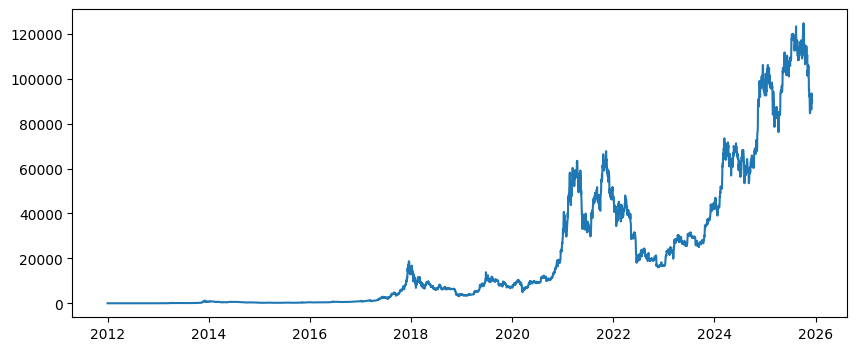

In [394]:
plt.figure(figsize=(10,4))
plt.plot(ts_bit_day.index,ts_bit_day['Close'])

In [395]:
ts_bit_day = ts_bit_day.add_suffix('_BTC')

In [396]:
ts_bit_day.head(2)

,Open_BTC,High_BTC,Low_BTC,Close_BTC,Volume_BTC
datetime,,,,,
2012-01-01 00:00:00+00:00,4.58,4.84,4.58,4.84,10.0
2012-01-02 00:00:00+00:00,4.84,5.00,4.84,5.00,10.1


# Solana

In [397]:
ts_solana.head(2)

,Дата,Открытие,Макс,Мин,Средняя,Закрыть,Изм.,Объём,Изм. Объема,Капитализ.,Изм. Капитализ.
0,2025-06-09,$152.43,$156.44,$149.93,$153.81,$156.44,2.63,"$2,262,193,512",66.65,"$82,118,168,854",2.57
1,2025-06-08,$150.11,$154.85,$148.24,$151.44,$152.55,1.63,"$1,357,439,380",-2.06,"$80,062,391,067",1.67


In [398]:
ts_solana['datetime'] = pd.to_datetime(ts_solana['Дата'])

ts_solana = ts_solana.reset_index(drop=True)

money_cols = ['Открытие', 'Макс', 'Мин', 'Средняя', 'Закрыть',
              'Объём', 'Капитализ.']

for col in money_cols:
    ts_solana[col] = (ts_solana[col]
                      .str.replace('$', '', regex=False)
                      .str.replace(',', '', regex=False)
                      .astype(float))

ts_solana = ts_solana.set_index('datetime')
ts_solana=ts_solana.drop('Дата',axis=1)
print(ts_solana.dtypes)
ts_solana.head()

Открытие           float64
Макс               float64
Мин                float64
Средняя            float64
Закрыть            float64
Изм.               float64
Объём              float64
Изм. Объема        float64
Капитализ.         float64
Изм. Капитализ.    float64
dtype: object


,Открытие,Макс,Мин,Средняя,Закрыть,Изм.,Объём,Изм. Объема,Капитализ.,Изм. Капитализ.
datetime,,,,,,,,,,
2025-06-09,152.43,156.44,149.93,153.81,156.44,2.63,2.262194e+09,66.65,8.211817e+10,2.57
2025-06-08,150.11,154.85,148.24,151.44,152.55,1.63,1.357439e+09,-2.06,8.006239e+10,1.67
2025-06-07,148.06,152.65,147.26,149.50,150.05,1.35,1.386026e+09,-30.98,7.874865e+10,1.42
2025-06-06,144.54,151.85,144.45,147.25,148.15,2.50,2.008109e+09,-40.09,7.764573e+10,2.53
2025-06-05,153.33,154.28,142.32,148.61,144.50,-5.76,3.351803e+09,70.89,7.573322e+10,-5.50


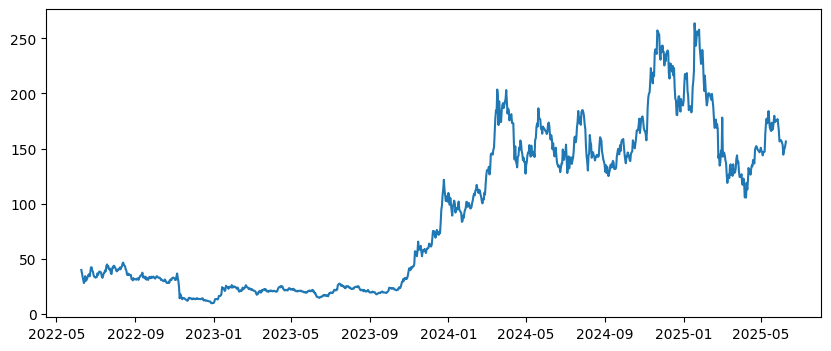

In [399]:
plt.figure(figsize=(10,4))
plt.plot(ts_solana.index,ts_solana['Закрыть'])

In [400]:
ts_solana = ts_solana.add_suffix('_sol')

In [401]:
ts_solana.head(2)

,Открытие_sol,Макс_sol,Мин_sol,Средняя_sol,Закрыть_sol,Изм._sol,Объём_sol,Изм. Объема_sol,Капитализ._sol,Изм. Капитализ._sol
datetime,,,,,,,,,,
2025-06-09,152.43,156.44,149.93,153.81,156.44,2.63,2.262194e+09,66.65,8.211817e+10,2.57
2025-06-08,150.11,154.85,148.24,151.44,152.55,1.63,1.357439e+09,-2.06,8.006239e+10,1.67


# Efir

In [402]:
ts_efir.head()

,Дата,Открытие,Макс,Мин,Средняя,Закрыть,Изм.,Объём,Изм. Объема,Капитализ.,Изм. Капитализ.
0,2025-06-09,"$2,509","$2,564","$2,482","$2,530","$2,564",2.180,"$6,363,313,461",35.52,"$309,550,694,998",2.20
1,2025-06-08,"$2,527","$2,541","$2,495","$2,518","$2,509",-0.699,"$4,695,476,215",16.93,"$302,895,144,740",-0.69
2,2025-06-07,"$2,480","$2,540","$2,463","$2,502","$2,526",1.890,"$4,015,470,520",-47.70,"$304,998,298,251",1.81
3,2025-06-06,"$2,418","$2,521","$2,407","$2,457","$2,481",2.620,"$7,678,377,029",-30.55,"$299,569,204,479",2.59
4,2025-06-05,"$2,610","$2,636","$2,408","$2,518","$2,419",-7.310,"$11,055,629,365",46.83,"$291,993,241,343",-7.33


In [403]:
ts_efir['datetime'] = pd.to_datetime(ts_efir['Дата'], errors='coerce')

ts_efir = ts_efir.set_index('datetime').sort_index()

price_cols = ['Открытие', 'Макс', 'Мин', 'Средняя', 'Закрыть']
money_cols = ['Объём', 'Капитализ.']

for col in price_cols + money_cols:
    ts_efir[col] = (ts_efir[col]
                    .str.replace('$', '', regex=False)
                    .str.replace(',', '', regex=False)
                    .astype(float))

pct_cols = ['Изм.', 'Изм. Объема', 'Изм. Капитализ.']
ts_efir[pct_cols] = ts_efir[pct_cols].apply(pd.to_numeric, errors='coerce')
ts_efir=ts_efir.drop("Дата",axis=1)
ts_efir.head()

,Открытие,Макс,Мин,Средняя,Закрыть,Изм.,Объём,Изм. Объема,Капитализ.,Изм. Капитализ.
datetime,,,,,,,,,,
2022-06-09,1788.0,1827.0,1777.0,1794.0,1786.0,-0.0763,3.517858e+09,NaN,2.163479e+11,NaN
2022-06-10,1784.0,1796.0,1658.0,1724.0,1658.0,-7.0700,5.942350e+09,68.92,2.008375e+11,-7.17
2022-06-11,1658.0,1676.0,1502.0,1590.0,1524.0,-8.0800,6.923228e+09,16.51,1.846590e+11,-8.06
2022-06-12,1527.0,1535.0,1428.0,1482.0,1439.0,-5.7700,7.525554e+09,8.70,1.742849e+11,-5.62
2022-06-13,1438.0,1444.0,1171.0,1313.0,1199.0,-16.5800,1.663284e+10,121.02,1.453201e+11,-16.62


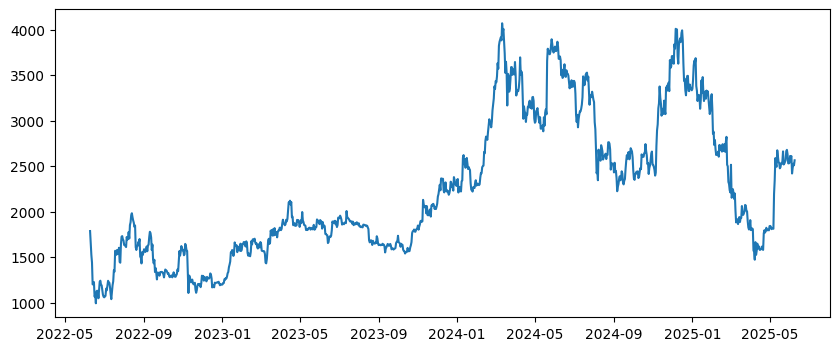

In [404]:
plt.figure(figsize=(10,4))
plt.plot(ts_efir.index,ts_efir['Закрыть'])

In [405]:
ts_efir = ts_efir.add_suffix('_efir')
ts_efir.head(2)

,Открытие_efir,Макс_efir,Мин_efir,Средняя_efir,Закрыть_efir,Изм._efir,Объём_efir,Изм. Объема_efir,Капитализ._efir,Изм. Капитализ._efir
datetime,,,,,,,,,,
2022-06-09,1788.0,1827.0,1777.0,1794.0,1786.0,-0.0763,3.517858e+09,NaN,2.163479e+11,NaN
2022-06-10,1784.0,1796.0,1658.0,1724.0,1658.0,-7.0700,5.942350e+09,68.92,2.008375e+11,-7.17


# Tether

In [406]:
tether=pd.read_csv(r"C:\Users\Kirill\Desktop\jupyter_projects\datasets_jupyter\tether-historical-data (2).csv")


In [407]:


tether['datetime'] = pd.to_datetime(tether['Дата'])
tether = tether.set_index('datetime').sort_index()
tether = tether.drop(columns=['Дата'])





In [408]:

tether.head(4)

,Открытие,Макс,Мин,Средняя,Закрыть,Изм.,Объём,Изм. Объема,Капитализ.,Изм. Капитализ.
datetime,,,,,,,,,,
2022-06-09,$0.999,$1.00,$0.998,$1.00,$0.999,-0.01790,"$14,393,511,949",NaN,"$72,432,579,636",NaN
2022-06-10,$0.999,$1.00,$0.999,$0.999,$0.999,-0.01440,"$17,230,823,241",19.71,"$72,421,876,212",-0.01480
2022-06-11,$0.999,$0.999,$0.999,$0.999,$0.999,0.00271,"$16,361,204,251",-5.05,"$72,424,144,870",0.00313
2022-06-12,$0.999,$0.999,$0.999,$0.999,$0.999,0.00341,"$20,573,871,168",25.75,"$72,223,890,515",-0.27700


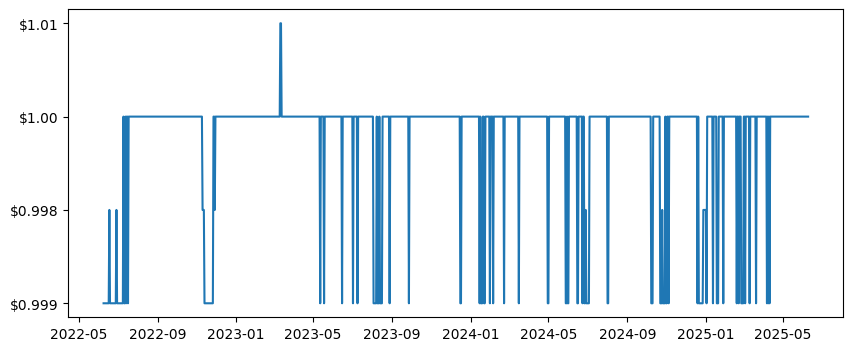

In [409]:
plt.figure(figsize=(10,4))
plt.plot(tether.index,tether['Закрыть'])

# Определяем границу среза

In [410]:
print(ts_bit_day.index.min())
print(ts_solana.index.min())
print(ts_efir.index.min())

2012-01-01 00:00:00+00:00
2022-06-09 00:00:00
2022-06-09 00:00:00


In [411]:
print(ts_solana.index.max())
print(ts_efir.index.max())

2025-06-09 00:00:00
2025-06-09 00:00:00


In [412]:
ts_bit_day.index = ts_bit_day.index.tz_localize(None)

In [413]:
ts_bit_day=ts_bit_day['2022-06-09':'2025-06-09']

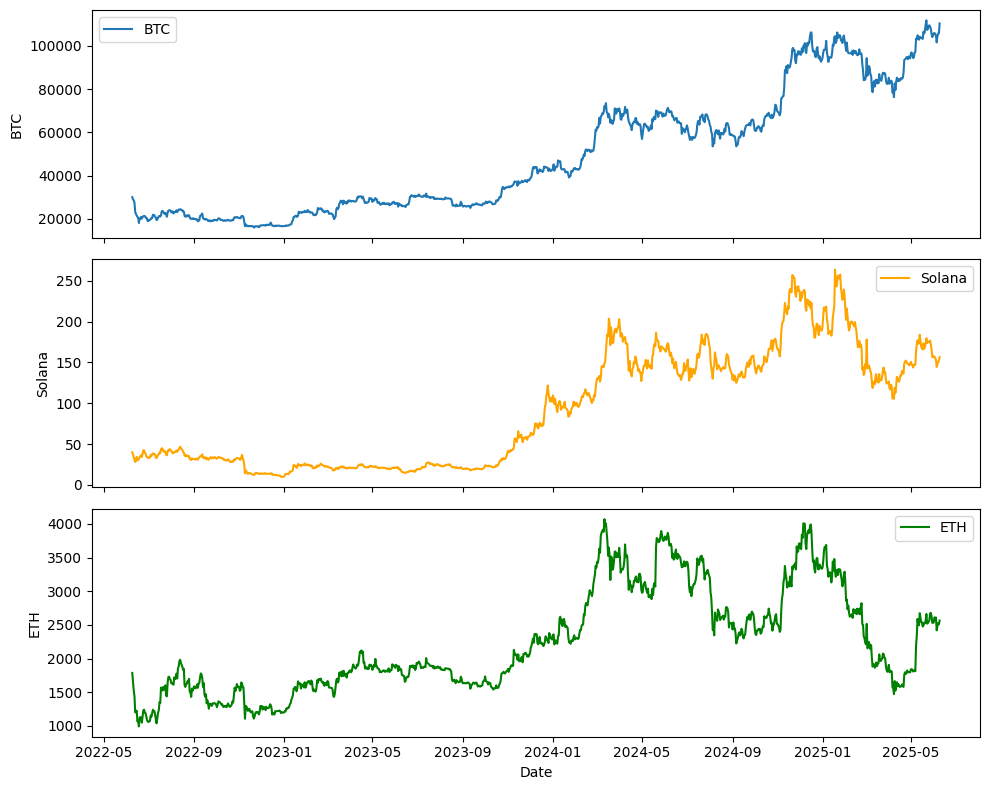

In [414]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].plot(ts_bit_day.index, ts_bit_day['Close_BTC'], label='BTC')
axes[0].set_ylabel('BTC')
axes[0].legend()

axes[1].plot(ts_solana.index, ts_solana['Закрыть_sol'], label='Solana', color='orange')
axes[1].set_ylabel('Solana')
axes[1].legend()

axes[2].plot(ts_efir.index, ts_efir['Закрыть_efir'], label='ETH', color='green')
axes[2].set_ylabel('ETH')
axes[2].legend()

plt.xlabel('Date')
plt.tight_layout()


# Соединяем

In [415]:
ts_all = pd.concat(
    [ts_bit_day,ts_solana, ts_efir],
    axis=1,      
    join='inner' 
)

ts_all.head()

,Open_BTC,High_BTC,Low_BTC,Close_BTC,Volume_BTC,Открытие_sol,Макс_sol,Мин_sol,Средняя_sol,Закрыть_sol,...,Открытие_efir,Макс_efir,Мин_efir,Средняя_efir,Закрыть_efir,Изм._efir,Объём_efir,Изм. Объема_efir,Капитализ._efir,Изм. Капитализ._efir
datetime,,,,,,,,,,,,,,,,,,,,,
2022-06-09,30117.01,30672.56,29920.56,29990.88,967.428486,38.77,41.59,38.53,39.70,39.90,...,1788.0,1827.0,1777.0,1794.0,1786.0,-0.0763,3.517858e+09,NaN,2.163479e+11,NaN
2022-06-10,29975.75,30333.81,28832.83,28937.05,2512.622358,39.85,40.64,37.00,38.63,37.04,...,1784.0,1796.0,1658.0,1724.0,1658.0,-7.0700,5.942350e+09,68.92,2.008375e+11,-7.17
2022-06-11,28951.83,29403.62,28085.75,28571.03,1665.995847,37.06,37.79,33.38,35.51,33.81,...,1658.0,1676.0,1502.0,1590.0,1524.0,-8.0800,6.923228e+09,16.51,1.846590e+11,-8.06
2022-06-12,28571.75,28656.81,26868.19,27387.23,2182.012839,33.86,34.18,30.71,32.36,30.71,...,1527.0,1535.0,1428.0,1482.0,1439.0,-5.7700,7.525554e+09,8.70,1.742849e+11,-5.62
2022-06-13,27383.72,27506.62,22600.00,23144.08,11560.651179,30.77,30.86,26.18,28.95,27.97,...,1438.0,1444.0,1171.0,1313.0,1199.0,-16.5800,1.663284e+10,121.02,1.453201e+11,-16.62


# Корреляции закрытия

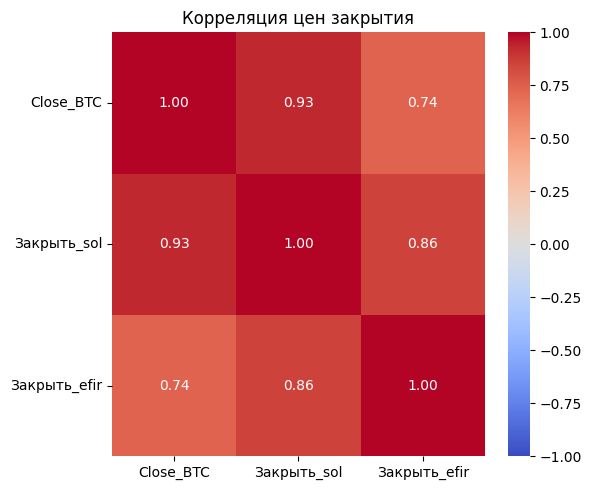

In [416]:

cols = ['Close_BTC', 'Закрыть_sol', 'Закрыть_efir']
corr = ts_all[cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    fmt='.2f',             
    annot_kws={'size': 10}  
)
plt.title('Корреляция цен закрытия')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# Корреляции всех исходных признаков

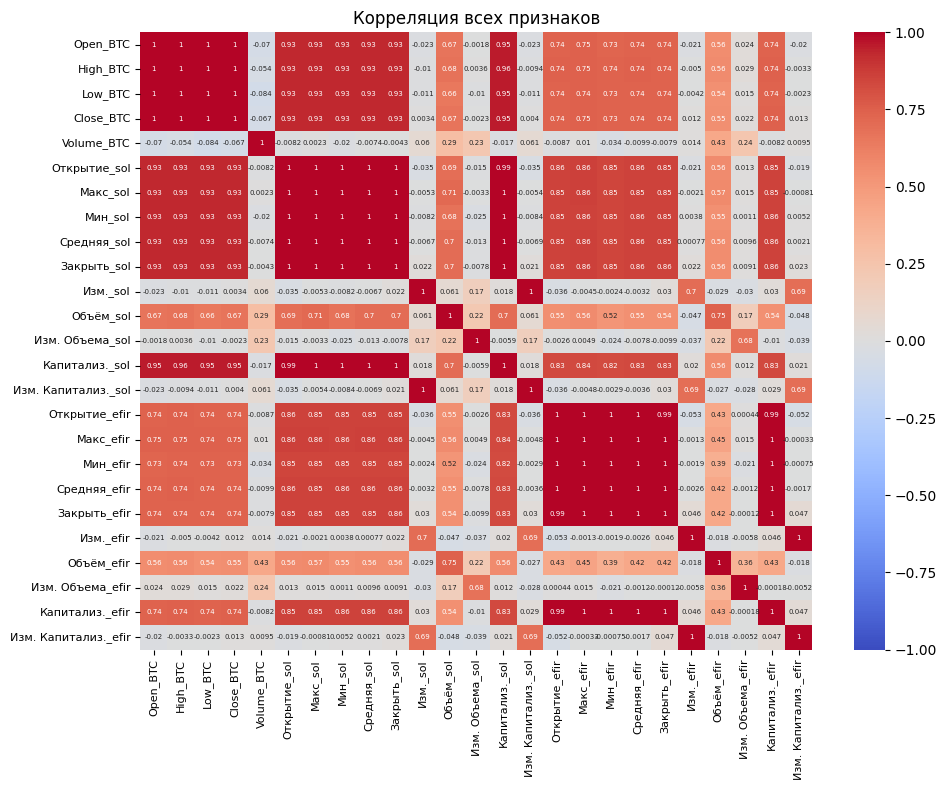

In [417]:

corr = ts_all.corr()

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    corr,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    annot=True,      
    square=False,
    annot_kws={'size':5}
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.title('Корреляция всех признаков')
plt.tight_layout()
plt.show()


# Добавление признаков

In [418]:
ts_all.shape

(1097, 25)

In [419]:
ts_all.columns

Index(['Open_BTC', 'High_BTC', 'Low_BTC', 'Close_BTC', 'Volume_BTC',
       'Открытие_sol', 'Макс_sol', 'Мин_sol', 'Средняя_sol', 'Закрыть_sol',
       'Изм._sol', 'Объём_sol', 'Изм. Объема_sol', 'Капитализ._sol',
       'Изм. Капитализ._sol', 'Открытие_efir', 'Макс_efir', 'Мин_efir',
       'Средняя_efir', 'Закрыть_efir', 'Изм._efir', 'Объём_efir',
       'Изм. Объема_efir', 'Капитализ._efir', 'Изм. Капитализ._efir'],
      dtype='object')

## Лаги

In [420]:
ts_all = ts_all.sort_values('datetime') 

ts_all['target_close_btc_1d'] = ts_all['Close_BTC'].shift(-1)

ts_all = ts_all[:-1].copy()  
ts_all = ts_all.reset_index(drop=False)  
ts_all = ts_all.dropna() 

for lag in [1, 2, 3,4,5,6, 7, 14, 28]:
    ts_all[f'Close_BTC_lag_{lag}'] = ts_all['Close_BTC'].shift(lag)

In [421]:
ts_all.head(15)

,datetime,Open_BTC,High_BTC,Low_BTC,Close_BTC,Volume_BTC,Открытие_sol,Макс_sol,Мин_sol,Средняя_sol,...,target_close_btc_1d,Close_BTC_lag_1,Close_BTC_lag_2,Close_BTC_lag_3,Close_BTC_lag_4,Close_BTC_lag_5,Close_BTC_lag_6,Close_BTC_lag_7,Close_BTC_lag_14,Close_BTC_lag_28
1,2022-06-10,29975.75,30333.81,28832.83,28937.05,2512.622358,39.85,40.64,37.00,38.63,...,28571.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-06-11,28951.83,29403.62,28085.75,28571.03,1665.995847,37.06,37.79,33.38,35.51,...,27387.23,28937.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-06-12,28571.75,28656.81,26868.19,27387.23,2182.012839,33.86,34.18,30.71,32.36,...,23144.08,28571.03,28937.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-06-13,27383.72,27506.62,22600.00,23144.08,11560.651179,30.77,30.86,26.18,28.95,...,22159.78,27387.23,28571.03,28937.05,NaN,NaN,NaN,NaN,NaN,NaN
5,2022-06-14,23147.74,23753.38,20816.35,22159.78,9056.313994,28.32,31.47,26.09,28.89,...,21592.60,23144.08,27387.23,28571.03,28937.05,NaN,NaN,NaN,NaN,NaN
6,2022-06-15,22159.78,22345.70,20079.72,21592.60,13498.109222,29.51,34.55,26.90,31.30,...,20848.73,22159.78,23144.08,27387.23,28571.03,28937.05,NaN,NaN,NaN,NaN
7,2022-06-16,21597.13,22957.01,20702.70,20848.73,4632.922907,34.62,35.42,29.76,32.46,...,20500.00,21592.60,22159.78,23144.08,27387.23,28571.03,28937.05,NaN,NaN,NaN
8,2022-06-17,20837.70,21325.06,20200.00,20500.00,4612.038343,29.93,32.00,29.36,30.50,...,18047.74,20848.73,21592.60,22159.78,23144.08,27387.23,28571.03,28937.05,NaN,NaN
9,2022-06-18,20497.41,20758.00,18004.95,18047.74,5586.189367,30.72,31.84,27.40,30.45,...,20090.03,20500.00,20848.73,21592.60,22159.78,23144.08,27387.23,28571.03,NaN,NaN
10,2022-06-19,18038.44,20278.47,17592.78,20090.03,7131.082194,31.85,35.03,28.94,32.49,...,20051.04,18047.74,20500.00,20848.73,21592.60,22159.78,23144.08,27387.23,NaN,NaN


In [422]:
ts_all.shape

(1095, 36)

## Скользящие окна по TR и BTC

In [423]:
for win in [3, 7, 14]:
    roll = ts_all['Close_BTC'].rolling(win)
    ts_all[f'btc_close_mean_{win}']   = roll.mean()
    ts_all[f'btc_close_std_{win}']    = roll.std()
    ts_all[f'btc_close_maxmin_{win}'] = roll.max() - roll.min()

high = ts_all['High_BTC']
low = ts_all['Low_BTC']
close_prev = ts_all['Close_BTC'].shift(1)

tr1 = high - low
tr2 = (high - close_prev).abs()
tr3 = (low - close_prev).abs()
ts_all['TR_BTC'] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

for win in [3, 7, 14]:
    ts_all[f'tr_btc_mean_{win}'] = ts_all['TR_BTC'].rolling(win).mean()

ts_all['vol_btc'] = ts_all['Volume_BTC']
for win in [3, 7, 14]:
    roll = ts_all['vol_btc'].rolling(win)
    ts_all[f'vol_btc_mean_{win}'] = roll.mean()
    ts_all[f'vol_btc_std_{win}']  = roll.std()


## SMA, EMA, RSI, MACD по BTC

In [424]:
ts_all['btc_sma_7']  = ts_all['Close_BTC'].rolling(7).mean()
ts_all['btc_ema_14'] = ts_all['Close_BTC'].ewm(span=14, adjust=False).mean()
ts_all['btc_ema_28'] = ts_all['Close_BTC'].ewm(span=28, adjust=False).mean()

window = 14
delta = ts_all['Close_BTC'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window).mean()
avg_loss = loss.rolling(window).mean()
rs = avg_gain / avg_loss
ts_all['rsi_14'] = 100 - (100 / (1 + rs))

ema12 = ts_all['Close_BTC'].ewm(span=12, adjust=False).mean()
ema26 = ts_all['Close_BTC'].ewm(span=26, adjust=False).mean()
ts_all['macd_line'] = ema12 - ema26
ts_all['macd_signal'] = ts_all['macd_line'].ewm(span=9, adjust=False).mean()
ts_all['macd_hist'] = ts_all['macd_line'] - ts_all['macd_signal']


## Признаки по Sol и ETH (лаги + окна)

In [425]:
for asset, close_col in [('sol', 'Закрыть_sol'), ('eth', 'Закрыть_efir')]:
    for lag in [1, 2, 3, 7, 14]:
        ts_all[f'{close_col}_lag_{lag}'] = ts_all[close_col].shift(lag)

for asset, close_col in [('sol', 'Закрыть_sol'), ('eth', 'Закрыть_efir')]:
    for win in [3, 7, 14]:
        roll = ts_all[close_col].rolling(win)
        ts_all[f'{asset}_close_mean_{win}']   = roll.mean()
        ts_all[f'{asset}_close_std_{win}']    = roll.std()
        ts_all[f'{asset}_close_maxmin_{win}'] = roll.max() - roll.min()

for asset, vol_col, cap_col in [
    ('sol', 'Объём_sol', 'Капитализ._sol'),
    ('eth', 'Объём_efir', 'Капитализ._efir'),
]:
    for win in [7, 14]:
        ts_all[f'{asset}_vol_mean_{win}'] = ts_all[vol_col].rolling(win).mean()
        ts_all[f'{asset}_cap_mean_{win}'] = ts_all[cap_col].rolling(win).mean()


# Чистка

In [426]:
cols_to_drop = [
    'Open_BTC',


    'Открытие_sol', 'Макс_sol', 'Мин_sol', 'Средняя_sol',
    'Изм._sol', 'Изм. Объема_sol', 'Изм. Капитализ._sol',

    'Открытие_efir', 'Макс_efir', 'Мин_efir', 'Средняя_efir',
    'Изм._efir', 'Изм. Объёма_efir', 'Изм. Капитализ._efir',
]

ts_all = ts_all.drop(columns=[c for c in cols_to_drop if c in ts_all.columns])
ts_all = ts_all.dropna(subset=['target_close_btc_1d'])


# Матрицы корреляций


## CLOSE/таргет/лаги: матрица корреляции

In [427]:
base_cols = [
    'Close_BTC',
    'Закрыть_sol',
    'Закрыть_efir',
    'target_close_btc_1d',
]

lag_cols_btc = [c for c in ts_all.columns if c.startswith('Close_BTC_lag_')]

lag_cols_sol = [c for c in ts_all.columns if c.startswith('Закрыть_sol_lag_')]
lag_cols_eth = [c for c in ts_all.columns if c.startswith('Закрыть_efir_lag_')]

corr_cols = base_cols + lag_cols_btc
corr_cols = base_cols + lag_cols_btc + lag_cols_sol + lag_cols_eth

corr_df = ts_all[corr_cols].corr()

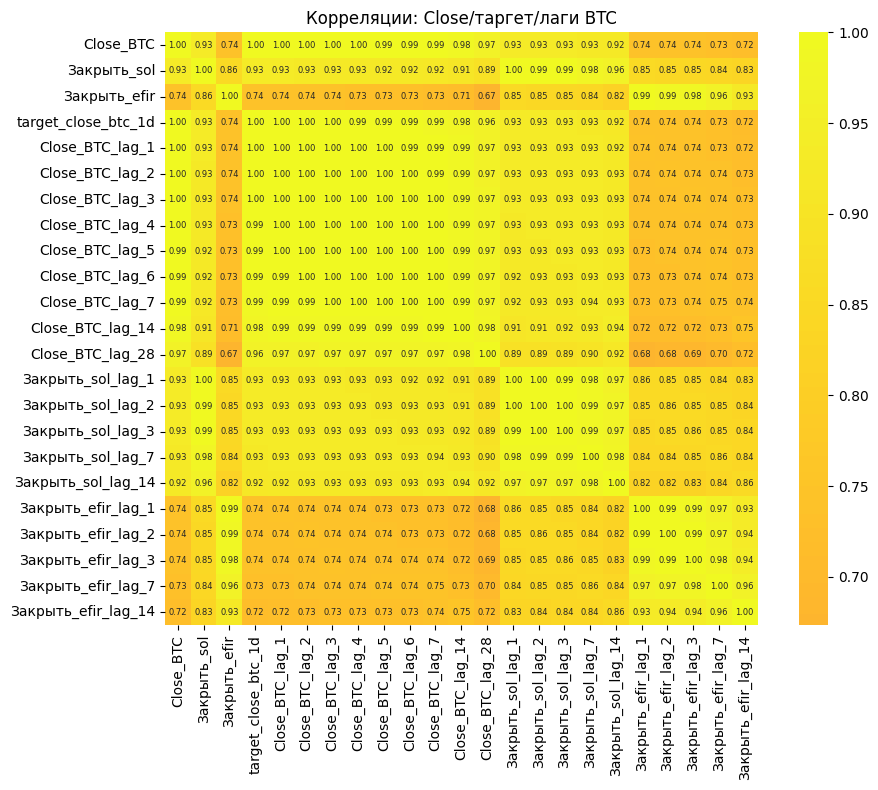

In [428]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_df,
    annot=True,
    fmt='.2f',
    cmap='plasma',
    center=0,
    square=True,
    annot_kws={'size': 6}
)
plt.title('Корреляции: Close/таргет/лаги BTC')
plt.tight_layout()



## BTC: Матрица корреляций

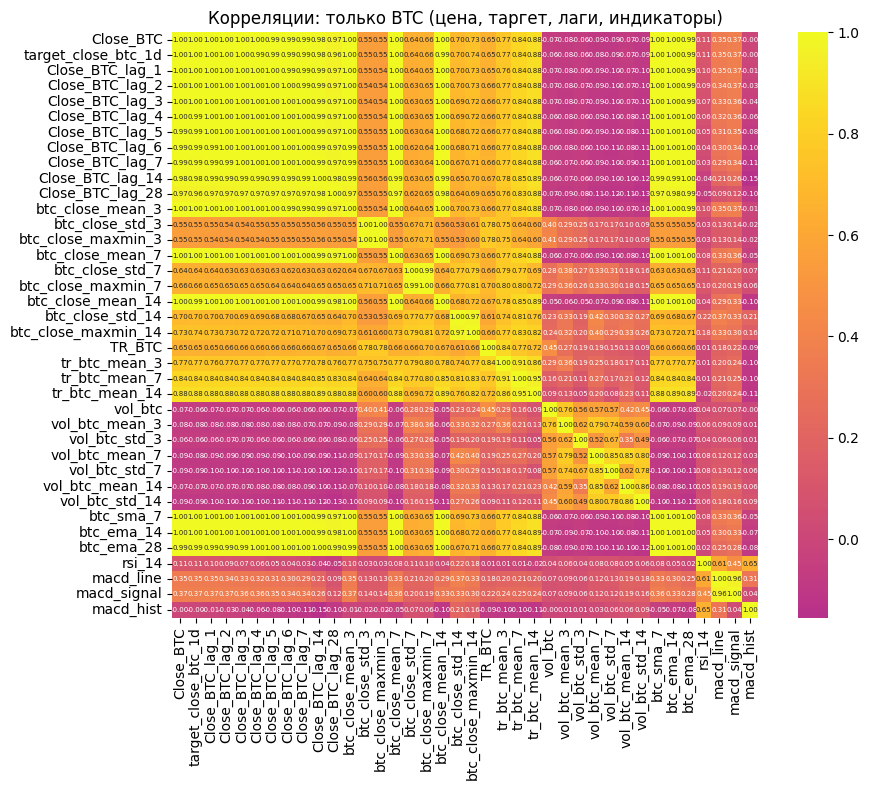

In [429]:
btc_cols = [
    'Close_BTC',
    'target_close_btc_1d',
]

btc_cols += [
    c for c in ts_all.columns
    if (
        c.startswith('Close_BTC_lag_') or
        c.startswith('btc_') or        
        c.startswith('vol_btc') or    
        c.startswith('tr_btc') or      
        c in ['TR_BTC', 'vol_btc', 'rsi_14', 'macd_line', 'macd_signal', 'macd_hist']
    )
]

btc_cols = list(dict.fromkeys([c for c in btc_cols if c in ts_all.columns]))

corr_btc = ts_all[btc_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_btc,
    annot=True,
    fmt='.2f',
    cmap='plasma',
    center=0,
    square=True,
    annot_kws={'size': 5}
)
plt.title('Корреляции: только BTC (цена, таргет, лаги, индикаторы)')
plt.tight_layout()

## ETH: Матрица корреляций

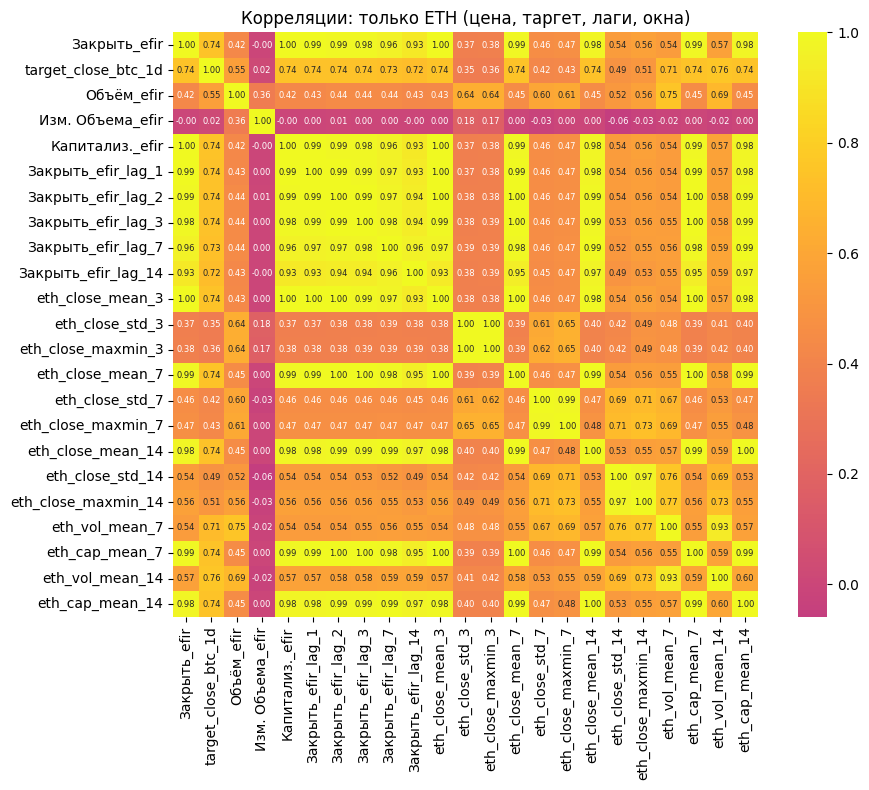

In [430]:
eth_cols = [
    'Закрыть_efir',
    'target_close_btc_1d',  
]

eth_cols += [
    c for c in ts_all.columns
    if (
        'efir' in c or      
        c.startswith('eth_')  
    )
]

eth_cols = list(dict.fromkeys([c for c in eth_cols if c in ts_all.columns]))

corr_eth = ts_all[eth_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_eth,
    annot=True,
    fmt='.2f',
    cmap='plasma',
    center=0,
    square=True,
    annot_kws={'size': 6}
)
plt.title('Корреляции: только ETH (цена, таргет, лаги, окна)')
plt.tight_layout()


## SOL:Матрица корреляций

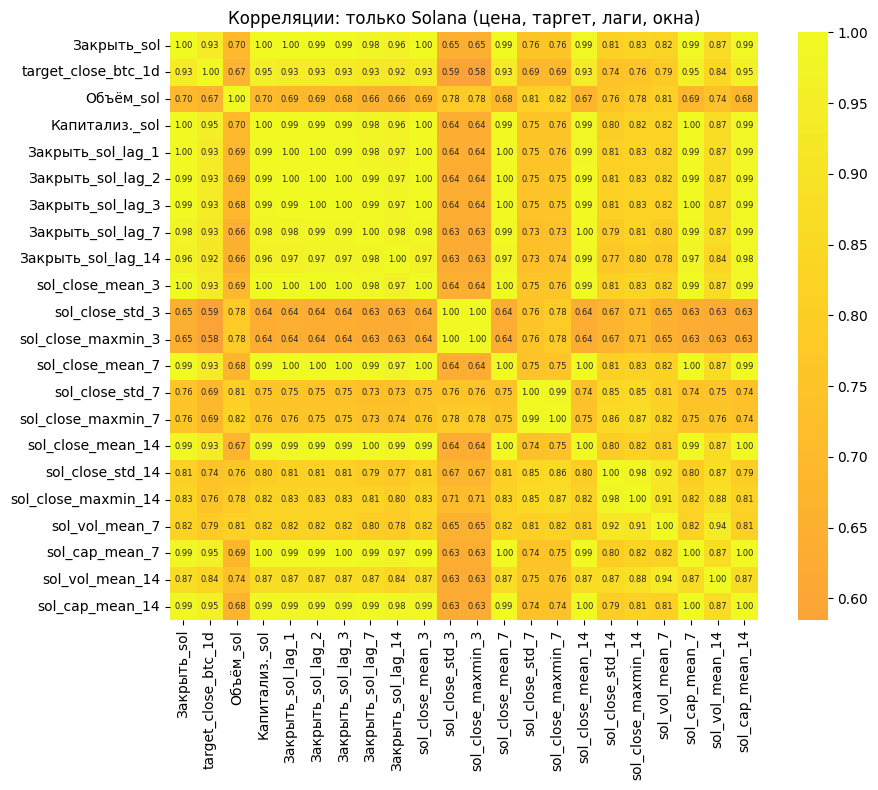

In [431]:
sol_cols = [
    'Закрыть_sol',
    'target_close_btc_1d',  
]

sol_cols += [
    c for c in ts_all.columns
    if (
        '_sol' in c or       
        c.startswith('sol_')  
    )
]

sol_cols = list(dict.fromkeys([c for c in sol_cols if c in ts_all.columns]))

corr_sol = ts_all[sol_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_sol,
    annot=True,
    fmt='.2f',
    cmap='plasma',
    center=0,
    square=True,
    annot_kws={'size': 6}
)
plt.title('Корреляции: только Solana (цена, таргет, лаги, окна)')
plt.tight_layout()


In [432]:
ts_all.shape

(1095, 85)

In [433]:
ts_all.head(2)

,datetime,High_BTC,Low_BTC,Close_BTC,Volume_BTC,Закрыть_sol,Объём_sol,Капитализ._sol,Закрыть_efir,Объём_efir,...,eth_close_std_14,eth_close_maxmin_14,sol_vol_mean_7,sol_cap_mean_7,sol_vol_mean_14,sol_cap_mean_14,eth_vol_mean_7,eth_cap_mean_7,eth_vol_mean_14,eth_cap_mean_14
1,2022-06-10,30333.81,28832.83,28937.05,2512.622358,37.04,784475459.0,1.266345e+10,1658.0,5.942350e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-06-11,29403.62,28085.75,28571.03,1665.995847,33.81,711719673.0,1.156550e+10,1524.0,6.923228e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [434]:
ts_all.shape

(1095, 85)

In [435]:
ts_all.columns

Index(['datetime', 'High_BTC', 'Low_BTC', 'Close_BTC', 'Volume_BTC',
       'Закрыть_sol', 'Объём_sol', 'Капитализ._sol', 'Закрыть_efir',
       'Объём_efir', 'Изм. Объема_efir', 'Капитализ._efir',
       'target_close_btc_1d', 'Close_BTC_lag_1', 'Close_BTC_lag_2',
       'Close_BTC_lag_3', 'Close_BTC_lag_4', 'Close_BTC_lag_5',
       'Close_BTC_lag_6', 'Close_BTC_lag_7', 'Close_BTC_lag_14',
       'Close_BTC_lag_28', 'btc_close_mean_3', 'btc_close_std_3',
       'btc_close_maxmin_3', 'btc_close_mean_7', 'btc_close_std_7',
       'btc_close_maxmin_7', 'btc_close_mean_14', 'btc_close_std_14',
       'btc_close_maxmin_14', 'TR_BTC', 'tr_btc_mean_3', 'tr_btc_mean_7',
       'tr_btc_mean_14', 'vol_btc', 'vol_btc_mean_3', 'vol_btc_std_3',
       'vol_btc_mean_7', 'vol_btc_std_7', 'vol_btc_mean_14', 'vol_btc_std_14',
       'btc_sma_7', 'btc_ema_14', 'btc_ema_28', 'rsi_14', 'macd_line',
       'macd_signal', 'macd_hist', 'Закрыть_sol_lag_1', 'Закрыть_sol_lag_2',
       'Закрыть_sol_lag_3', '

In [436]:
ts_all.head(2)

,datetime,High_BTC,Low_BTC,Close_BTC,Volume_BTC,Закрыть_sol,Объём_sol,Капитализ._sol,Закрыть_efir,Объём_efir,...,eth_close_std_14,eth_close_maxmin_14,sol_vol_mean_7,sol_cap_mean_7,sol_vol_mean_14,sol_cap_mean_14,eth_vol_mean_7,eth_cap_mean_7,eth_vol_mean_14,eth_cap_mean_14
1,2022-06-10,30333.81,28832.83,28937.05,2512.622358,37.04,784475459.0,1.266345e+10,1658.0,5.942350e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-06-11,29403.62,28085.75,28571.03,1665.995847,33.81,711719673.0,1.156550e+10,1524.0,6.923228e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [437]:
ts_all.columns

Index(['datetime', 'High_BTC', 'Low_BTC', 'Close_BTC', 'Volume_BTC',
       'Закрыть_sol', 'Объём_sol', 'Капитализ._sol', 'Закрыть_efir',
       'Объём_efir', 'Изм. Объема_efir', 'Капитализ._efir',
       'target_close_btc_1d', 'Close_BTC_lag_1', 'Close_BTC_lag_2',
       'Close_BTC_lag_3', 'Close_BTC_lag_4', 'Close_BTC_lag_5',
       'Close_BTC_lag_6', 'Close_BTC_lag_7', 'Close_BTC_lag_14',
       'Close_BTC_lag_28', 'btc_close_mean_3', 'btc_close_std_3',
       'btc_close_maxmin_3', 'btc_close_mean_7', 'btc_close_std_7',
       'btc_close_maxmin_7', 'btc_close_mean_14', 'btc_close_std_14',
       'btc_close_maxmin_14', 'TR_BTC', 'tr_btc_mean_3', 'tr_btc_mean_7',
       'tr_btc_mean_14', 'vol_btc', 'vol_btc_mean_3', 'vol_btc_std_3',
       'vol_btc_mean_7', 'vol_btc_std_7', 'vol_btc_mean_14', 'vol_btc_std_14',
       'btc_sma_7', 'btc_ema_14', 'btc_ema_28', 'rsi_14', 'macd_line',
       'macd_signal', 'macd_hist', 'Закрыть_sol_lag_1', 'Закрыть_sol_lag_2',
       'Закрыть_sol_lag_3', '

# Make_sequences

In [438]:

def make_sequences(X, y, dates, seq_len):
    X_seq, y_seq, d_seq = [], [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])       
        d_seq.append(dates[i+seq_len])   
    return np.array(X_seq), np.array(y_seq), np.array(d_seq)

ts_all=ts_all.dropna()


# Функция для метрик

In [439]:
def metrics(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    err = y_true - y_pred  

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    denom = np.maximum(np.abs(y_true), eps)
    mape = np.mean(np.abs(err) / denom) * 100.0  

    wmape = (np.sum(np.abs(err)) / np.maximum(np.sum(np.abs(y_true)), eps)) * 100.0  

    bias = np.sum(err)

    mad = np.mean(np.abs(err))

    ts = bias / np.maximum(mad, eps)  

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE_%": mape,
        "WMAPE_%": wmape,
        "Bias_CFE": bias
    }

import numpy as np

def _zscore(a, eps=1e-8):
    a = np.asarray(a, dtype=float)
    return (a - a.mean()) / (a.std() + eps)

def dtw_distance(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    n, m = len(a), len(b)
    D = np.full((n+1, m+1), np.inf, dtype=float)
    D[0, 0] = 0.0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(a[i-1] - b[j-1])
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return D[n, m]

def geometry_shape_score(y_true, y_pred, use_derivative=True, eps=1e-8):
    yt = _zscore(y_true, eps=eps)
    yp = _zscore(y_pred, eps=eps)

    d1 = dtw_distance(yt, yp) / max(len(yt), 1)

    if use_derivative:
        d2 = dtw_distance(np.diff(yt), np.diff(yp)) / max(len(yt)-1, 1)
        d = 0.5 * (d1 + d2)
    else:
        d = d1

    score = 1.0 / (1.0 + d)
    return {"DTW_level_norm": d1, "DTW_deriv_norm": (d2 if use_derivative else None), "ShapeScore_0_1": score}




### MAE (Mean Absolute Error)
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$



### RMSE (Root Mean Squared Error)
$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$


### MAPE (Mean Absolute Percentage Error)
$$MAPE = \frac{100}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

Средняя процентная ошибка. Позволяет сравнивать рряды разных масштабов.

### WMAPE (Weighted Mean Absolute Percentage Error)
$$WMAPE = \frac{100 \sum_{i=1}^{n} |y_i - \hat{y}_i|}{\sum_{i=1}^{n} |y_i|}$$

Взвешенная MAPE. Более стабильна, чем MAPE.

### Bias (CFE)
$$Bias = \sum_{i=1}^{n} (y_i - \hat{y}_i)$$

Кумулятивная ошибка. Показывает систематическое смещение:
- Bias ≈ 0: нет смещения 
- Bias > 0: модель недооценивает
- Bias < 0: модель переоценивает



### Z-score нормализация
$$z_i = \frac{x_i - \mu}{\sigma + \varepsilon}$$

Приводит ряды к стандартному виду (среднее = 0, стд. отклонение = 1).


### DTW Distance (Dynamic Time Warping)
Динамическое выравнивание временных рядов с учетом временных сдвигов:

$$D[i,j] = |a_i - b_j| + \min(D[i-1,j], D[i,j-1], D[i-1,j-1])$$

Нормализованное: $d_1 = \frac{DTW(a,b)}{n}$
**Диапазон:** 0 до ∞

**Интерпретация:**
- **DTW ≈ 0** = Ряды идеально совпадают (форма и уровни)
- **DTW = 0.1-0.3** = Очень хорошее совпадение 
- **DTW = 0.3-0.5** = Хорошее совпадение 
- **DTW > 0.5** = Слабое совпадение 

### DTW производных
$$d_2 = \frac{DTW(\nabla y, \nabla \hat{y})}{n-1}$$

**Диапазон:** 0 до ∞

**Интерпретация:**
- **DTW_deriv ≈ 0** = Одинаковая **динамика изменений** (тренды совпадают)
- **DTW_deriv = 0.1-0.2** = Очень хорошее совпадение тренда 
- **DTW_deriv = 0.2-0.4** = Хорошее совпадение тренда
- **DTW_deriv > 0.4** = Разные тренды 


Оценивает совпадение скоростей изменения (трендов).


### Shape Score (геометрическое сходство)
$$ShapeScore = \frac{1}{1 + d}, \quad d = 0.5 \cdot d_1 + 0.5 \cdot d_2$$

**Диапазон:** 0 до 1
- 1.0 = идеальное совпадение формы
- 0.5 = среднее совпадение
- ≈0 = формы совершенно разные

Не зависит от масштаба и амплитуды ряда.


## Сравнение метрик

| Метрика | Тип | Лучшее значение | Когда использовать |
|---------|-----|-----------------|-------------------|
| MAE | Ошибка | 0 | Все случаи |
| RMSE | Ошибка | 0 | Когда важны большие ошибки |
| MAPE | % ошибка | 0% | Сравнение разных масштабов |
| WMAPE | % ошибка | 0% | Стабильнее MAPE |
| Bias | Смещение | 0 | Диагностика систематических ошибок |
| ShapeScore | Сходство | 1 | Оценка совпадения формы тренда |


# BTC


## BTC данные

In [440]:
seq_len = 28  

ts_all = ts_all.dropna(subset=['target_close_btc_1d']).reset_index(drop=True)
feature_cols = [c for c in ts_all.columns
                if c not in ['datetime', 'target_close_btc_1d','target_close_sol_1d','target_close_eth_1d']]

X_raw = ts_all[feature_cols].values
y_raw = ts_all['target_close_btc_1d'].values
dates = ts_all['datetime'].values


X_seq, y_seq, dates_seq = make_sequences(X_raw, y_raw, dates, seq_len)


In [441]:
n = len(X_seq)
n_val = int(0.20 * n)
X_train = X_seq[:n-n_val]  
X_val = X_seq[n-n_val:]     
y_train = y_seq[:n-n_val]   
y_val = y_seq[n-n_val:]
dates_train, dates_val = dates_seq[:n-n_val], dates_seq[n-n_val:]

n_features = X_train.shape[2]
scaler = StandardScaler()
X_train_2d = X_train.reshape(-1, n_features)
scaler.fit(X_train_2d)

def scale_seq(X, scaler):
    s = X.shape
    X2 = X.reshape(-1, s[2])
    X2 = scaler.transform(X2)
    return X2.reshape(s)

X_train_scaled = scale_seq(X_train, scaler)
X_val_scaled   = scale_seq(X_val, scaler)
X_full_scaled  = scale_seq(X_seq, scaler)

y_train_log = np.log(y_train)
y_val_log   = np.log(y_val)
y_full_log  = np.log(y_seq)



## Модель BiLSTM

In [442]:
model_bit_bilstm = Sequential([
    Bidirectional(
        LSTM(256, return_sequences=False),
        input_shape=(seq_len, n_features)
    ),
    Dense(64, activation='relu'),

    Dense(64, activation='relu'),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1)
])


c:\Users\Kirill\anaconda3\envs\common_classic\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## BiLSTM обучние

In [443]:
model_bit_bilstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='mse',
    metrics=['mae']
)

es_bit_bilstm = EarlyStopping(
    monitor='val_loss',
    patience=40,
    restore_best_weights=True
)

history_bit_bilstm = model_bit_bilstm.fit(
    X_train_scaled, y_train_log,
    validation_data=(X_val_scaled, y_val_log),
    epochs=150,
    batch_size=64,
    callbacks=[es_bit_bilstm],
    verbose=1)

Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 65.2424 - mae: 7.7416 - val_loss: 8.5501 - val_mae: 2.8527
Epoch 2/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 7.6199 - mae: 2.2684 - val_loss: 1.4464 - val_mae: 1.1421
Epoch 3/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 4.5130 - mae: 1.6525 - val_loss: 1.4625 - val_mae: 1.1808
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 3.5929 - mae: 1.4591 - val_loss: 0.0722 - val_mae: 0.2242
Epoch 5/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 3.2117 - mae: 1.4424 - val_loss: 0.5689 - val_mae: 0.7288
Epoch 6/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 3.3207 - mae: 1.4435 - val_loss: 0.0467 - val_mae: 0.1777
Epoch 7/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 3.2734 - mae: 1.4260 - val_loss: 0.0873 - val_mae: 0.2719
Epoch 8/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 3.0093 - mae: 1.3882 - val_loss: 0.1233 - val_mae: 0.3301
Epoch 9/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - l

## BiLSTM график обучения

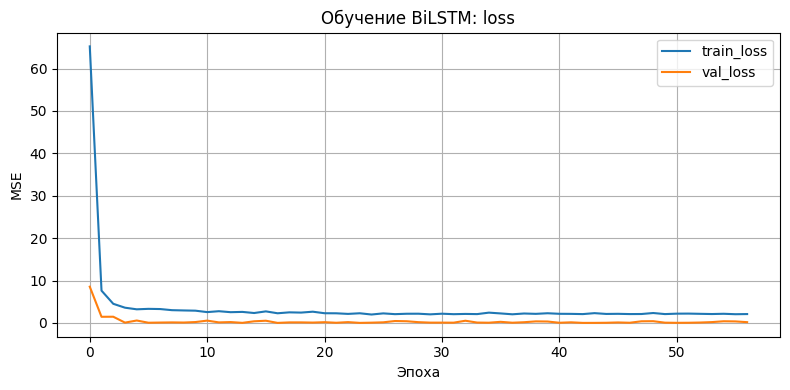

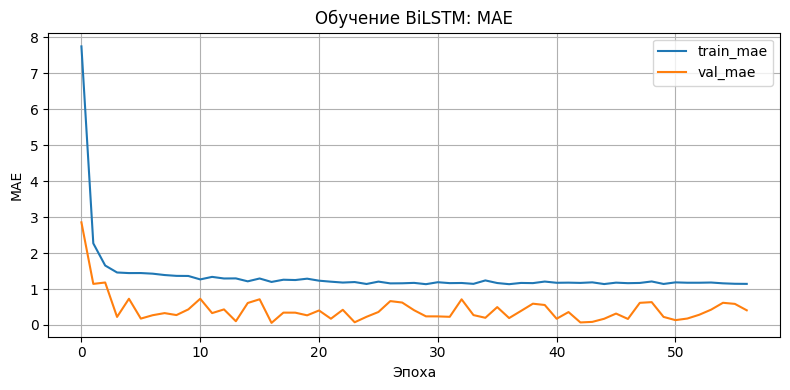

In [444]:
plt.figure(figsize=(8,4))
plt.plot(history_bit_bilstm.history['loss'], label='train_loss')
plt.plot(history_bit_bilstm.history['val_loss'], label='val_loss')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.title('Обучение BiLSTM: loss')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.figure(figsize=(8, 4))
plt.plot(history_bit_bilstm.history['mae'], label='train_mae')
plt.plot(history_bit_bilstm.history['val_mae'], label='val_mae')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.title('Обучение BiLSTM: MAE')
plt.legend()
plt.grid(True)
plt.tight_layout()

## BiLSTM метрики

In [445]:
y_train_pred_log_bilstm = model_bit_bilstm.predict(X_train_scaled).squeeze()
y_val_pred_log_bilstm   = model_bit_bilstm.predict(X_val_scaled).squeeze()

y_train_pred_bilstm = np.exp(y_train_pred_log_bilstm)
y_val_pred_bilstm   = np.exp(y_val_pred_log_bilstm)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


In [446]:


val_m_bilstm   = metrics(y_val,   y_val_pred_bilstm)


print("BTC BiLSTM metrics")
for k,v in val_m_bilstm.items():
    print(f"{k:20s}: {v:,.4f}" if "MAPE" not in k and "WMAPE" not in k else f"{k:20s}: {v:,.4f}%")

print(geometry_shape_score(y_val, y_val_pred_bilstm, use_derivative=True, eps=1e-8))




BTC BiLSTM metrics
RMSE                : 7,503.0891
MAE                 : 5,546.4038
MAPE_%              : 5.7922%
WMAPE_%             : 5.8219%
Bias_CFE            : 27,981.6719
{'DTW_level_norm': np.float64(0.3483208054394752), 'DTW_deriv_norm': np.float64(0.26952481698831027), 'ShapeScore_0_1': np.float64(0.7639869910072097)}


## BiLSTM график предикта

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


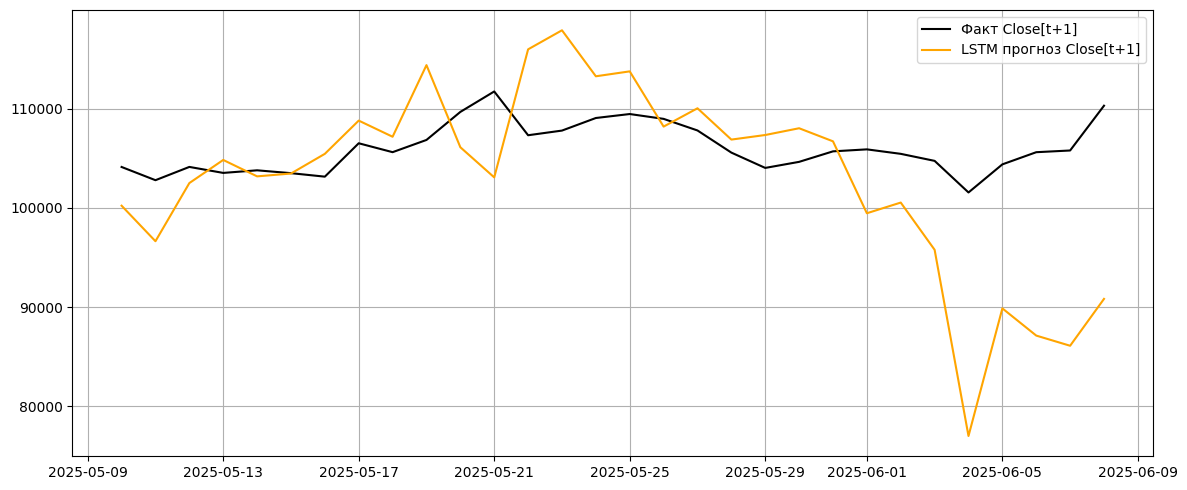

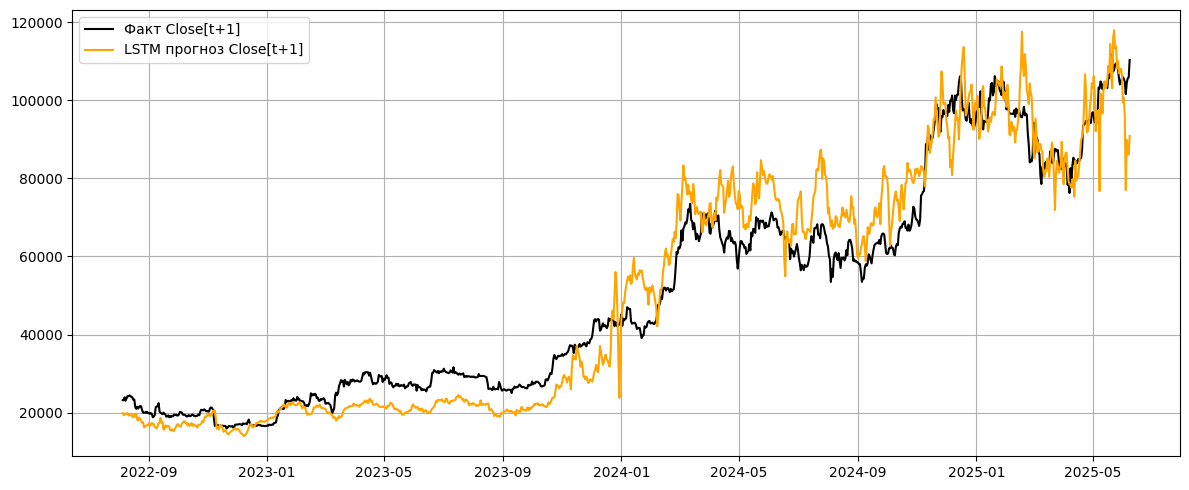

In [447]:
y_pred_full_log_bilstm = model_bit_bilstm.predict(X_full_scaled).squeeze()
y_pred_full_bit_bilstm = np.exp(y_pred_full_log_bilstm)

assert len(dates_seq) == len(y_seq) == len(y_pred_full_bit_bilstm)
datespredtarget = dates_seq 
plt.figure(figsize=(12,5))
plt.plot(datespredtarget[-30:], y_seq[-30:], label='Факт Close[t+1]',color='black')
plt.plot(datespredtarget[-30:], y_pred_full_bit_bilstm[-30:], label='LSTM прогноз Close[t+1]',color='orange')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.figure(figsize=(12,5))
plt.plot(datespredtarget, y_seq, label='Факт Close[t+1]',color='black')
plt.plot(datespredtarget, y_pred_full_bit_bilstm, label='LSTM прогноз Close[t+1]',color='orange')
plt.legend()
plt.grid(True)
plt.tight_layout()

## GRU модель

In [448]:

model_bit_gru = Sequential([
    Bidirectional(
        GRU(256, return_sequences=False),
        input_shape=(seq_len, n_features)
    ),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)  
])

c:\Users\Kirill\anaconda3\envs\common_classic\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## GRU обучение 

In [449]:

model_bit_gru.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='mse',
    metrics=['mae']
)

es_bit_gru = EarlyStopping(
    monitor='val_loss',
    patience=40,
    restore_best_weights=True
)

history_bit_gru = model_bit_gru.fit(
    X_train_scaled, y_train_log,
    validation_data=(X_val_scaled, y_val_log),
    epochs=150,
    batch_size=64,
    callbacks=[es_bit_gru],
    verbose=1
)


Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 68.0460 - mae: 7.9400 - val_loss: 5.5720 - val_mae: 2.2343
Epoch 2/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 13.9388 - mae: 3.0675 - val_loss: 2.0719 - val_mae: 1.3900
Epoch 3/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 7.8733 - mae: 2.2104 - val_loss: 1.2353 - val_mae: 1.0818
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 5.9830 - mae: 1.9889 - val_loss: 0.6409 - val_mae: 0.7634
Epoch 5/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 4.3294 - mae: 1.6321 - val_loss: 0.0547 - val_mae: 0.1807
Epoch 6/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 3.2650 - mae: 1.4046 - val_loss: 0.1893 - val_mae: 0.3933
Epoch 7/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 2.8618 - mae: 1.3568 - val_loss: 0.5665 - val_mae: 0.7430
Epoch 8/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 2.3434 - mae: 1.2221 - val_loss: 0.9002 - val_mae: 0.9417
Epoch 9/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - 

## GRU график обучения

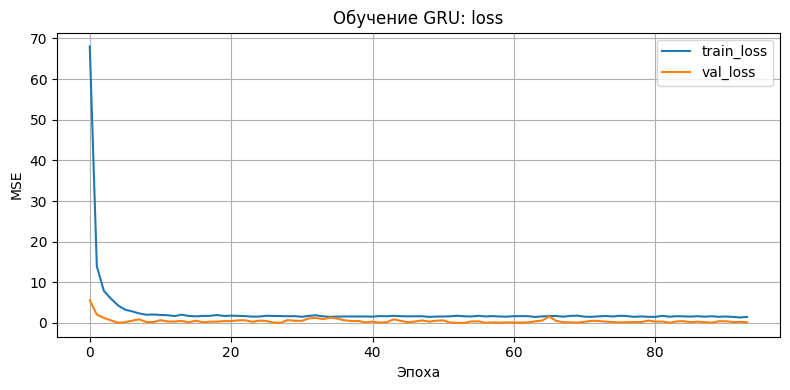

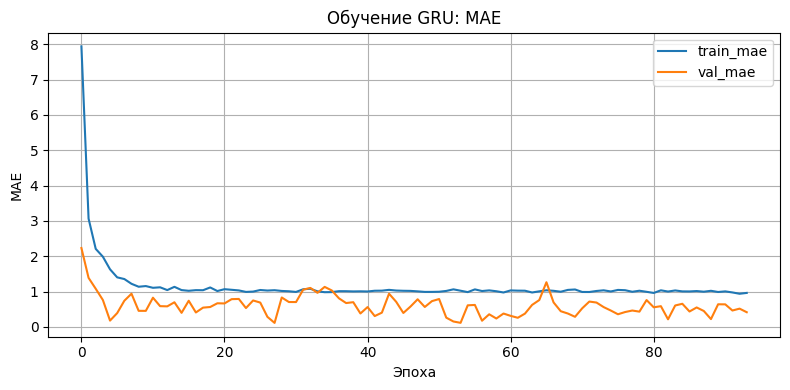

In [450]:


plt.figure(figsize=(8,4))
plt.plot(history_bit_gru.history['loss'], label='train_loss')
plt.plot(history_bit_gru.history['val_loss'], label='val_loss')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.title('Обучение GRU: loss')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.figure(figsize=(8,4))
plt.plot(history_bit_gru.history['mae'], label='train_mae')
plt.plot(history_bit_gru.history['val_mae'], label='val_mae')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.title('Обучение GRU: MAE')
plt.legend()
plt.grid(True)
plt.tight_layout()


## GRU метрики

In [451]:


y_train_pred_log_gru = model_bit_gru.predict(X_train_scaled).squeeze()
y_val_pred_log_gru   = model_bit_gru.predict(X_val_scaled).squeeze()

y_train_pred_gru = np.exp(y_train_pred_log_gru)
y_val_pred_gru   = np.exp(y_val_pred_log_gru)

val_m_gru = metrics(y_val, y_val_pred_gru)
print("BTC GRU metrics ")
for k, v in val_m_gru.items():
    print(f"{k:20s}: {v:,.4f}" if "MAPE" not in k and "WMAPE" not in k else f"{k:20s}: {v:,.4f}%")

print(geometry_shape_score(y_val, y_val_pred_gru, use_derivative=True, eps=1e-8))


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
BTC GRU metrics 
RMSE                : 12,977.3304
MAE                 : 10,506.2709
MAPE_%              : 11.0542%
WMAPE_%             : 11.0280%
Bias_CFE            : 1,333,241.1055
{'DTW_level_norm': np.float64(0.4517490545615313), 'DTW_deriv_norm': np.float64(0.1941180011500509), 'ShapeScore_0_1': np.float64(0.7558958775659717)}


## GRU график предикта

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


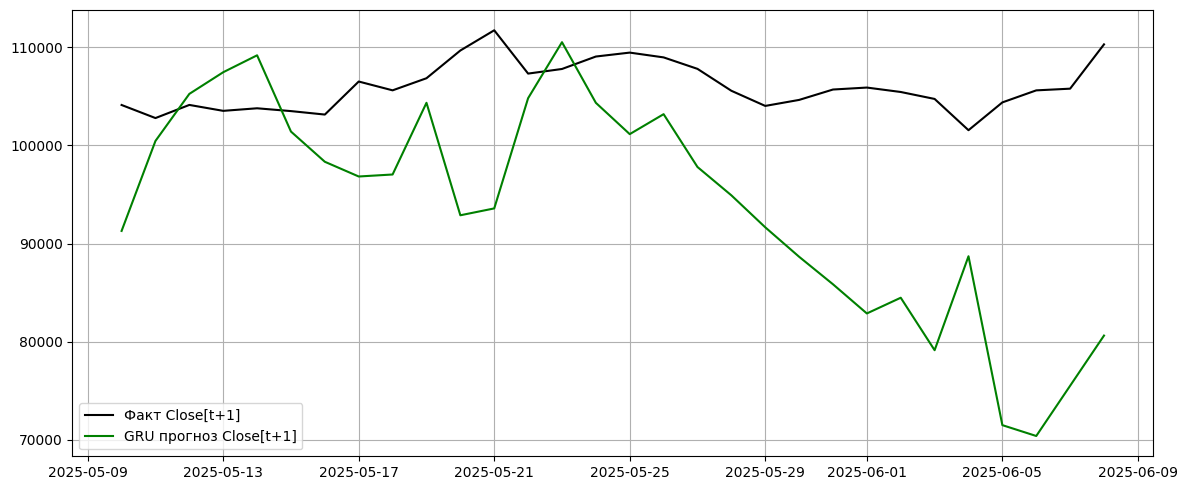

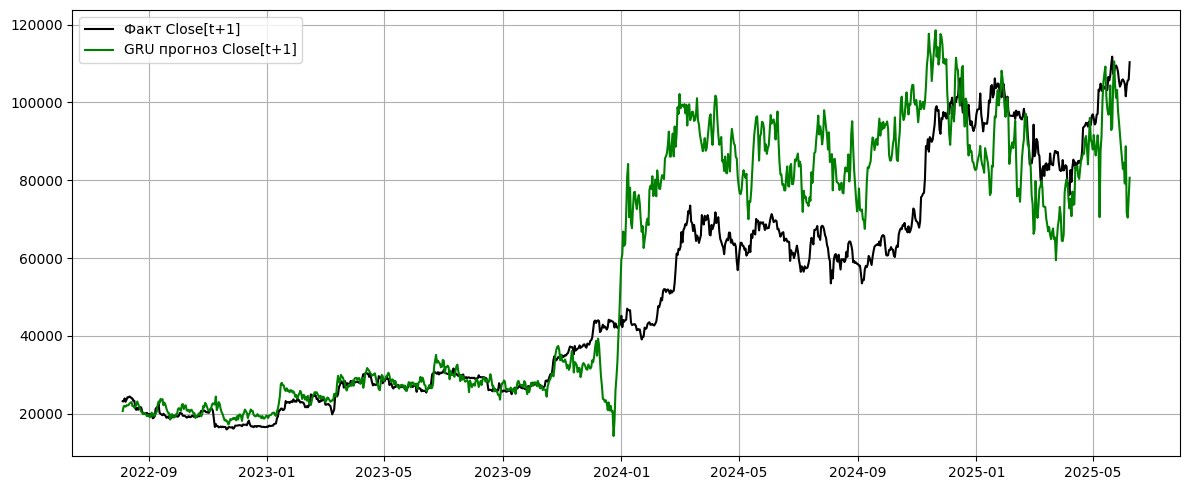

In [452]:
y_pred_full_log_gru = model_bit_gru.predict(X_full_scaled).squeeze()
y_pred_full_gru = np.exp(y_pred_full_log_gru)

plt.figure(figsize=(12,5))
plt.plot(dates_seq[-30:], y_seq[-30:], label='Факт Close[t+1]',color='black')
plt.plot(dates_seq[-30:], y_pred_full_gru[-30:], label='GRU прогноз Close[t+1]',color='green')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.figure(figsize=(12,5))
plt.plot(dates_seq, y_seq, label='Факт Close[t+1]',color='black')
plt.plot(dates_seq, y_pred_full_gru, label='GRU прогноз Close[t+1]',color='green')
plt.legend()
plt.grid(True)
plt.tight_layout()


## LSTM модель

In [453]:

model_bit_lstm = Sequential([
    LSTM(256, return_sequences=False, input_shape=(seq_len, n_features)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1) 
])


c:\Users\Kirill\anaconda3\envs\common_classic\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## LSTM обучние

In [454]:

model_bit_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='mse',
    metrics=['mae']
)

es_lstm = EarlyStopping(
    monitor='val_loss',
    patience=40,
    restore_best_weights=True
)

history_lstm = model_bit_lstm.fit(
    X_train_scaled, y_train_log,
    validation_data=(X_val_scaled, y_val_log),
    epochs=150,
    batch_size=64,
    callbacks=[es_lstm],
    verbose=1
)


Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 74.7568 - mae: 8.4945 - val_loss: 40.2079 - val_mae: 6.3309
Epoch 2/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 13.4731 - mae: 3.0760 - val_loss: 1.7078 - val_mae: 1.2770
Epoch 3/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 6.4328 - mae: 2.1103 - val_loss: 0.1182 - val_mae: 0.2732
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 4.4081 - mae: 1.6649 - val_loss: 0.9951 - val_mae: 0.9817
Epoch 5/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 4.2284 - mae: 1.6485 - val_loss: 0.0257 - val_mae: 0.1370
Epoch 6/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 3.8946 - mae: 1.5588 - val_loss: 0.1880 - val_mae: 0.4090
Epoch 7/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 3.3171 - mae: 1.4551 - val_loss: 0.0536 - val_mae: 0.1945
Epoch 8/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 3.4005 - mae: 1.4664 - val_loss: 0.2214 - val_mae: 0.4615
Epoch 9/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step -

## LSTM график обучниея

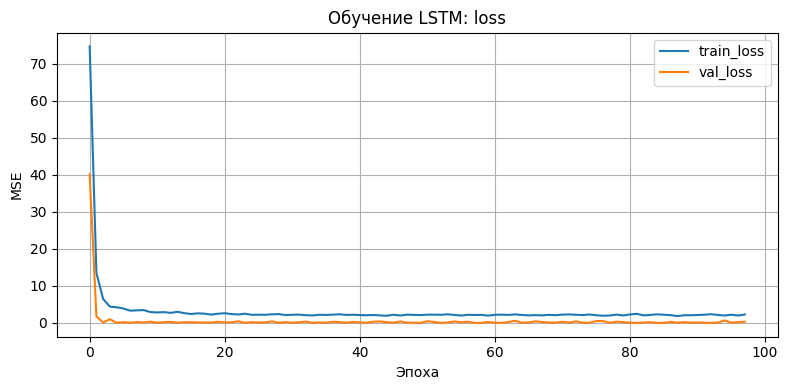

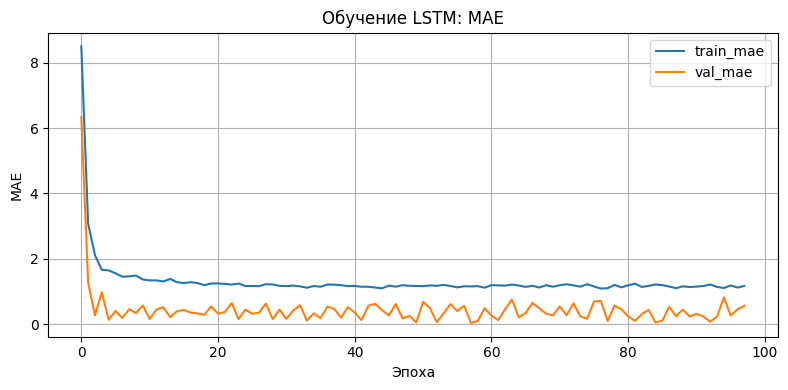

In [455]:

plt.figure(figsize=(8,4))
plt.plot(history_lstm.history['loss'], label='train_loss')
plt.plot(history_lstm.history['val_loss'], label='val_loss')
plt.xlabel('Эпоха'); plt.ylabel('MSE')
plt.title('Обучение LSTM: loss')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.figure(figsize=(8,4))
plt.plot(history_lstm.history['mae'], label='train_mae')
plt.plot(history_lstm.history['val_mae'], label='val_mae')
plt.xlabel('Эпоха'); plt.ylabel('MAE')
plt.title('Обучение LSTM: MAE')
plt.legend()
plt.grid(True)
plt.tight_layout()


## LSTM метрики

In [456]:

y_val_pred_log_lstm = model_bit_lstm.predict(X_val_scaled).squeeze()
y_val_pred_lstm = np.exp(y_val_pred_log_lstm)

val_m_lstm = metrics(y_val, y_val_pred_lstm)
print("BTC LSTM metrics ")

for k, v in val_m_lstm.items():
    print(f"{k:20s}: {v:,.4f}" if "MAPE" not in k and "WMAPE" not in k else f"{k:20s}: {v:,.4f}%")

print(geometry_shape_score(y_val, y_val_pred_lstm, use_derivative=True, eps=1e-8))


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
BTC LSTM metrics 
RMSE                : 5,022.7493
MAE                 : 4,051.1816
MAPE_%              : 4.3609%
WMAPE_%             : 4.2524%
Bias_CFE            : -268,019.7344
{'DTW_level_norm': np.float64(0.2684887252553848), 'DTW_deriv_norm': np.float64(0.21375304726021435), 'ShapeScore_0_1': np.float64(0.8057232869677812)}


## LSTM предикт

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


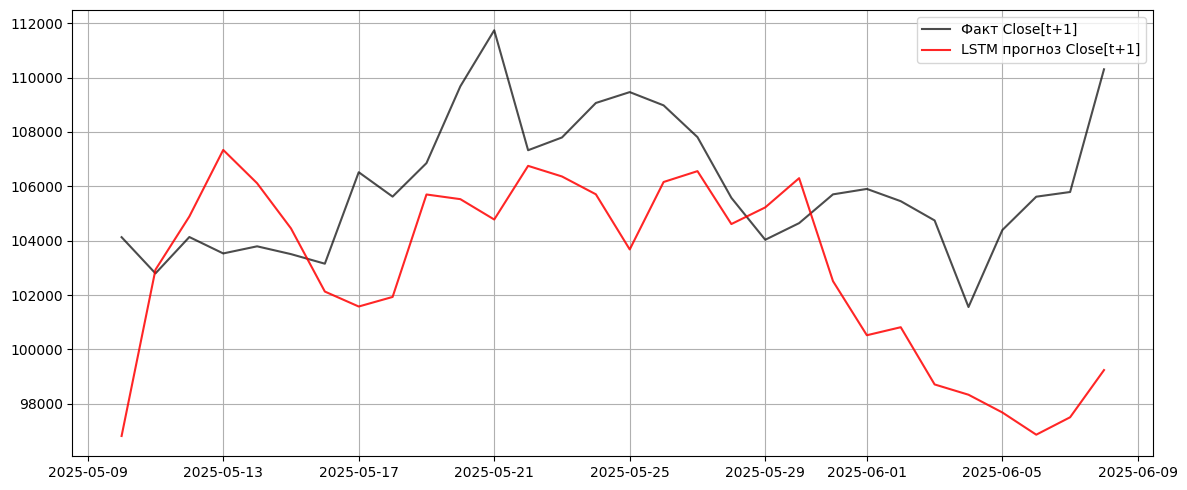

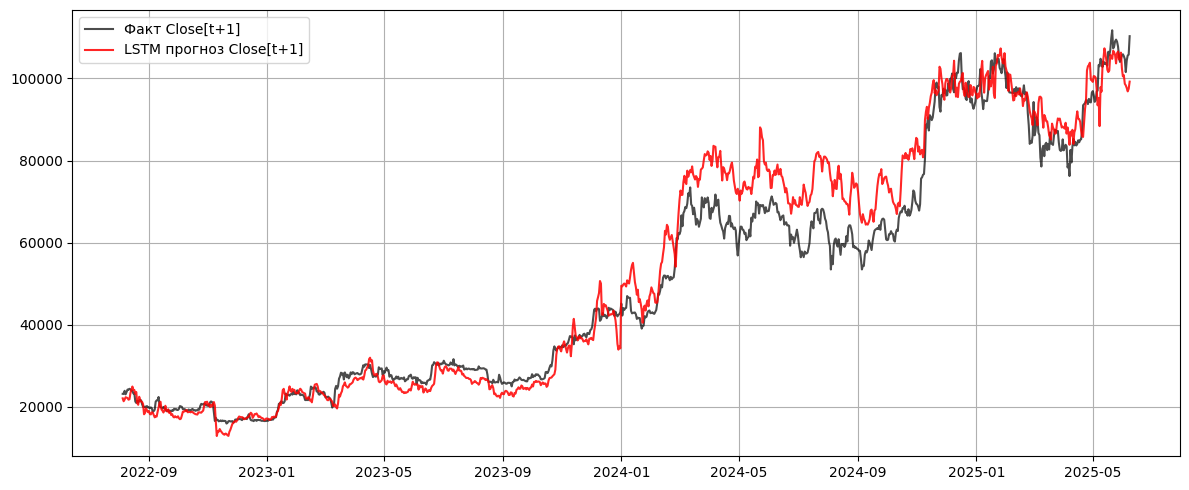

In [457]:
y_pred_full_log_lstm = model_bit_lstm.predict(X_full_scaled).squeeze()
y_pred_full_lstm = np.exp(y_pred_full_log_lstm)

plt.figure(figsize=(12,5))
plt.plot(dates_seq[-30:], y_seq[-30:], label='Факт Close[t+1]', alpha=0.7,color='black')
plt.plot(dates_seq[-30:], y_pred_full_lstm[-30:], label='LSTM прогноз Close[t+1]', alpha=0.85,color='red')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.figure(figsize=(12,5))
plt.plot(dates_seq, y_seq, label='Факт Close[t+1]', alpha=0.7,color='black')
plt.plot(dates_seq, y_pred_full_lstm, label='LSTM прогноз Close[t+1]', alpha=0.85,color='red')
plt.legend()
plt.grid(True)
plt.tight_layout()


## BTC GRU vs LSTM vs BiLSTM

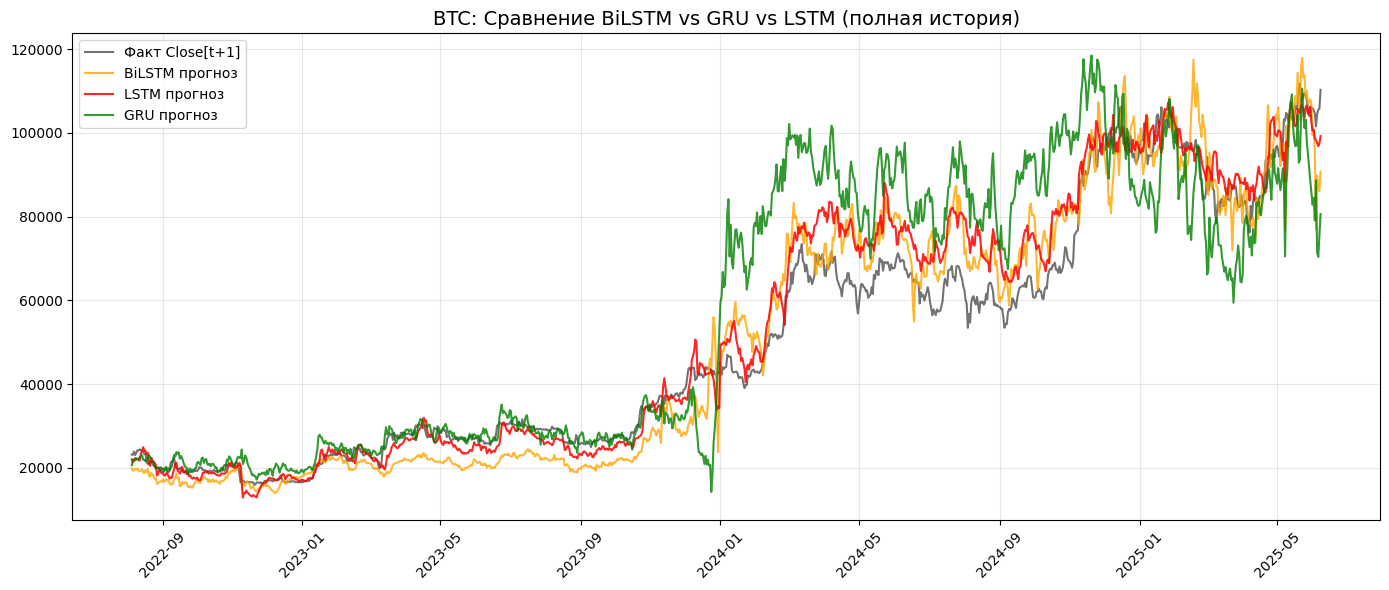

In [458]:

plt.figure(figsize=(14,6))
plt.plot(dates_seq, y_seq, label='Факт Close[t+1]', alpha=0.55,color='black')
plt.plot(dates_seq, y_pred_full_bit_bilstm, label='BiLSTM прогноз', alpha=0.80,color='orange')
plt.plot(dates_seq, y_pred_full_lstm, label='LSTM прогноз', alpha=0.85,color='red')
plt.plot(dates_seq, y_pred_full_gru, label='GRU прогноз', alpha=0.80,color='green')
plt.xticks(rotation=45)
plt.legend()
plt.title('BTC: Сравнение BiLSTM vs GRU vs LSTM (полная история)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()



## Полная таблица метрик

| Model | RMSE | MAE | MAPE_% | WMAPE_% | ShapeScore | DTW_level | DTW_deriv | Bias_CFE |
|-------|------|-----|--------|---------|------------|-----------|-----------|----------|
| **BTC LSTM** | 5,022.75 | 4,051.18 | 4.36% | 4.25%| 0.8057|0.2685| 0.2138 | -268,020 |
| **BTC GRU** | 12,977.33 | 10,506.27 | 11.05% | 11.03% | 0.7559 | 0.4517 | 0.1941 | +1,333,241 |
| **BTC BiLSTM** | 7,503.09 | 5,546.40 | 5.79% | 5.82% | 0.7640 | 0.3483 | 0.2695 | +27,982 |

##  Лучшие модели по метрикам

| Метрика | Лучшая модель | Значение | Результат |
|---------|---------------|----------|-----------|
| **RMSE**  | BTC LSTM | 5,022.75 |  Минимальная квадратическая ошибка |
| **MAE**  | BTC LSTM | 4,051.18 |  Минимальная абсолютная ошибка |
| **MAPE**  | BTC LSTM | 4.36% |  Минимальная процентная ошибка |
| **WMAPE**  | BTC LSTM | 4.25% | Минимальная взвешенная ошибка |
| **ShapeScore** | BTC LSTM | 0.8057 | Лучшее совпадение формы тренда |
| **DTW_level** | BTC LSTM | 0.2685 | Минимальное расстояние по уровням |


***LSTM*** имеет лучшие показатели метрик из всех моделей.

### LSTM vs GRU

| Метрика | BTC GRU | BTC LSTM | Улучшение |
|---------|---------|---------|-----------|
| RMSE | 12,977.33 | 5,022.75 | **61.3%**  |
| MAE | 10,506.27 | 4,051.18 | * 61.4%**  |
| MAPE | 11.05% | 4.36% | **60.5%**  |
| WMAPE | 11.03% | 4.25% | **61.5%** |
| ShapeScore | 0.7559 | 0.8057 | **6.6%** |

**Вывод:** LSTM на **~61% лучше** чем  GRU по всем метрикам ошибок

### LSTM vs BiLSTM

| Метрика | BTC BiLSTM | BTC LSTM | Улучшение |
|---------|-----------|---------|-----------|
| RMSE | 7,503.09 | 5,022.75 | **33.1%**  |
| MAE | 5,546.40 | 4,051.18 | **27.0%**  |
| MAPE | 5.79% | 4.36% | **24.7%** |
| WMAPE | 5.82% | 4.25% | **27.0%**  |
| ShapeScore | 0.7640 | 0.8057 | **5.5%** |

**Вывод:** LSTM на **~27-33% лучше** чем BTC BiLSTM по метрикам ошибок.



### Точность прогноза (RMSE/MAE)
```
BTC LSTM    5,022.75
BTC BiLSTM  7,503.09
BTC GRU     12,977.33
```

### Процентная ошибка (MAPE)
```
BTC LSTM    4.36%  
BTC BiLSTM  5.79%
BTC GRU     11.05%
```

### Форма тренда (ShapeScore)
```
BTC LSTM    0.8057  
BTC BiLSTM  0.7640
BTC GRU     0.7559
```


###  Систематическое смещение (Bias)

| Model | Bias_CFE | Интерпретация |
|-------|----------|----------------|
| **BTC LSTM** | **-268,020** | Модель немного переоценивает |
| **BTC BiLSTM** | **+27,982** | Практически нулевое смещение   |
| **BTC GRU** | **+1,333,241** | Слишком резкие скачки |




### DTW анализ (динамическое выравнивание)

| Model | DTW_level | DTW_deriv | Комментарий |
|-------|-----------|-----------|-------------|
| **BTC LSTM** | 0.2685| 0.2138 | Минимальное искажение по уровням |
| **BTC BiLSTM** | 0.3483 | 0.2695| Баланс между уровнями и производными |
| **BTC GRU** | 0.4517 | 0.1941 | Плохое совпадение по уровням |


##  Финальные выводы

###  BTC LSTM - лучшая модель

**Лучший по:**
- RMSE: 5,022.75 (на 61% лучше GRU, на 33% лучше BiLSTM)
- MAE: 4,051.18 (на 61% лучше GRU, на 27% лучше BiLSTM)
- MAPE: 4.36% (на 61% лучше GRU, на 25% лучше BiLSTM)
- WMAPE: 4.25% (на 62% лучше GRU, на 27% лучше BiLSTM)
- ShapeScore: 0.8057 (на 7% лучше GRU и BiLSTM)
- DTW_level: 0.2685 (минимальное расстояние)



###  BTC BiLSTM - средняя модель

**Преимущества:**
- Хороший баланс точности (5.79% MAPE)
- **Лучший Bias** (+27,982 ≈ 0) - нет систематических ошибок
- Стабильная форма тренда (0.7640 ShapeScore)

Может быть резервной моделью, если нужна минимальная систематическая ошибка.

### BTC GRU -худшая модель

**Проблемы:**
-  На 61% хуже LSTM по всем ошибкам
-  На 65% хуже BiLSTM по RMSE
-  Огромное систематическое смещение (+1.3M)
-  Худшее совпадение по DTW_level

**BTC GRU худщая модель**




# EfIR

### EFIR данные

In [459]:
ts_all.isna().sum()

datetime           0
High_BTC           0
Low_BTC            0
Close_BTC          0
Volume_BTC         0
                  ..
sol_cap_mean_14    0
eth_vol_mean_7     0
eth_cap_mean_7     0
eth_vol_mean_14    0
eth_cap_mean_14    0
Length: 85, dtype: int64

In [460]:
ts_all['target_close_eth_1d'] = ts_all['Закрыть_efir'].shift(-1)

ts_all = ts_all[:-1].copy()
ts_all = ts_all.dropna(subset=['target_close_eth_1d']).reset_index(drop=True)

feature_cols = [
    c for c in ts_all.columns
    if c not in ['datetime', 'target_close_btc_1d','target_close_sol_1d','target_close_eth_1d']
]

X_raw = ts_all[feature_cols].values
y_raw = ts_all['target_close_eth_1d'].values
dates = ts_all['datetime'].values


In [461]:
seq_len_eth = 28 


X_seq, y_seq, dates_seq = make_sequences(X_raw, y_raw, dates, seq_len_eth)


In [462]:
n = len(X_seq)
n_val = int(0.20 * n)
X_train = X_seq[:n-n_val]   
X_val = X_seq[n-n_val:]      
y_train = y_seq[:n-n_val]    
y_val = y_seq[n-n_val:]
dates_train, dates_val = dates_seq[:n-n_val], dates_seq[n-n_val:]

from sklearn.preprocessing import StandardScaler
n_features = X_train.shape[2]
scaler = StandardScaler()
X_train_2d = X_train.reshape(-1, n_features)
scaler.fit(X_train_2d)

def scale_seq(X, scaler):
    s = X.shape
    X2 = X.reshape(-1, s[2])
    X2 = scaler.transform(X2)
    return X2.reshape(s)

X_train_scaled = scale_seq(X_train, scaler)
X_val_scaled   = scale_seq(X_val,   scaler)
X_full_scaled  = scale_seq(X_seq,   scaler)

y_train_log = np.log(y_train)
y_val_log   = np.log(y_val)
y_full_log  = np.log(y_seq)


##  BiLSTM модель

In [463]:

model_eth_blstm = Sequential([
    Bidirectional(LSTM(256, return_sequences=False),
                  input_shape=(seq_len, n_features)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1)   
])

model_eth_blstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='mse',
    metrics=['mae']
)

c:\Users\Kirill\anaconda3\envs\common_classic\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## BiLSTM обучение

In [464]:


es_eth_blstm = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_eth_blstm = model_eth_blstm.fit(
    X_train_scaled, y_train_log,
    validation_data=(X_val_scaled, y_val_log),
    epochs=150,
    batch_size=64,
    callbacks=[es_eth_blstm],
    verbose=1
)


Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 35.4790 - mae: 5.6778 - val_loss: 3.0944 - val_mae: 1.7252
Epoch 2/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 4.3285 - mae: 1.6767 - val_loss: 0.5358 - val_mae: 0.6895
Epoch 3/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 2.4614 - mae: 1.2312 - val_loss: 0.0518 - val_mae: 0.1871
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 1.7729 - mae: 1.0574 - val_loss: 0.0610 - val_mae: 0.2030
Epoch 5/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 1.9052 - mae: 1.0900 - val_loss: 0.0378 - val_mae: 0.1603
Epoch 6/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 1.4775 - mae: 0.9437 - val_loss: 0.0367 - val_mae: 0.1544
Epoch 7/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 1.4923 - mae: 0.9757 - val_loss: 0.0574 - val_mae: 0.1940
Epoch 8/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 1.5926 - mae: 0.9887 - val_loss: 0.1569 - val_mae: 0.3561
Epoch 9/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - l

## BiLSTM график обучение

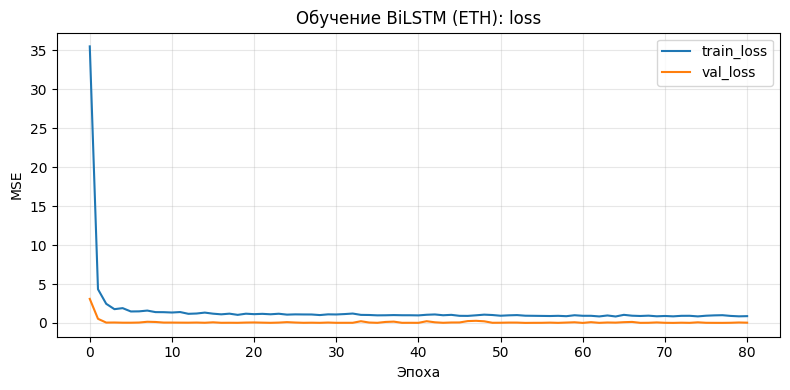

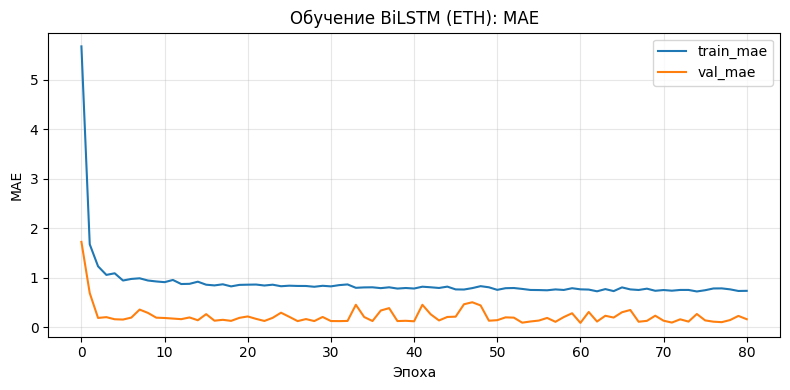

In [465]:

plt.figure(figsize=(8, 4))
plt.plot(history_eth_blstm.history['loss'],     label='train_loss')
plt.plot(history_eth_blstm.history['val_loss'], label='val_loss')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.title('Обучение BiLSTM (ETH): loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.figure(figsize=(8, 4))
plt.plot(history_eth_blstm.history['mae'],     label='train_mae')
plt.plot(history_eth_blstm.history['val_mae'], label='val_mae')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.title('Обучение BiLSTM (ETH): MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()


## BiLSTM Метрики

In [466]:


y_train_pred_log_blstm = model_eth_blstm.predict(X_train_scaled).squeeze()
y_val_pred_log_blstm   = model_eth_blstm.predict(X_val_scaled).squeeze()

y_train_pred_blstm = np.exp(y_train_pred_log_blstm)
y_val_pred_blstm   = np.exp(y_val_pred_log_blstm)


val_m   = metrics(y_val,   y_val_pred_blstm)

print("ETH BiLSTM metrics ")

for k,v in val_m.items():
    print(f"{k:20s}: {v:,.4f}" if "MAPE" not in k and "WMAPE" not in k else f"{k:20s}: {v:,.4f}%")

print( geometry_shape_score(y_val, y_val_pred_blstm, use_derivative=True, eps=1e-8))




26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
ETH BiLSTM metrics 
RMSE                : 302.2356
MAE                 : 229.6501
MAPE_%              : 8.4222%
WMAPE_%             : 8.5752%
Bias_CFE            : 23,151.0930
{'DTW_level_norm': np.float64(0.15370764915159604), 'DTW_deriv_norm': np.float64(0.11113907561992606), 'ShapeScore_0_1': np.float64(0.8830619653529799)}


## BiLSTM график предикта

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


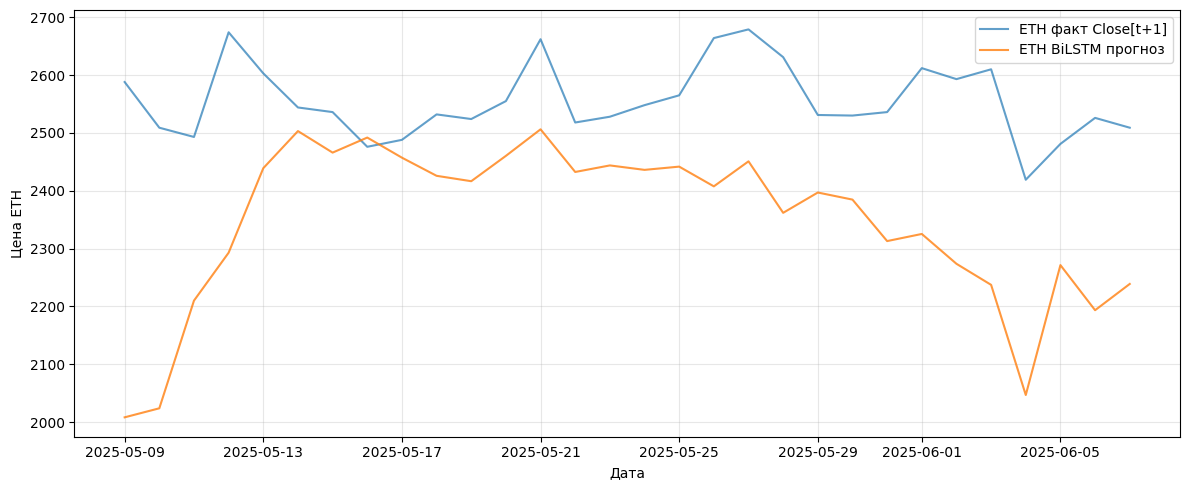

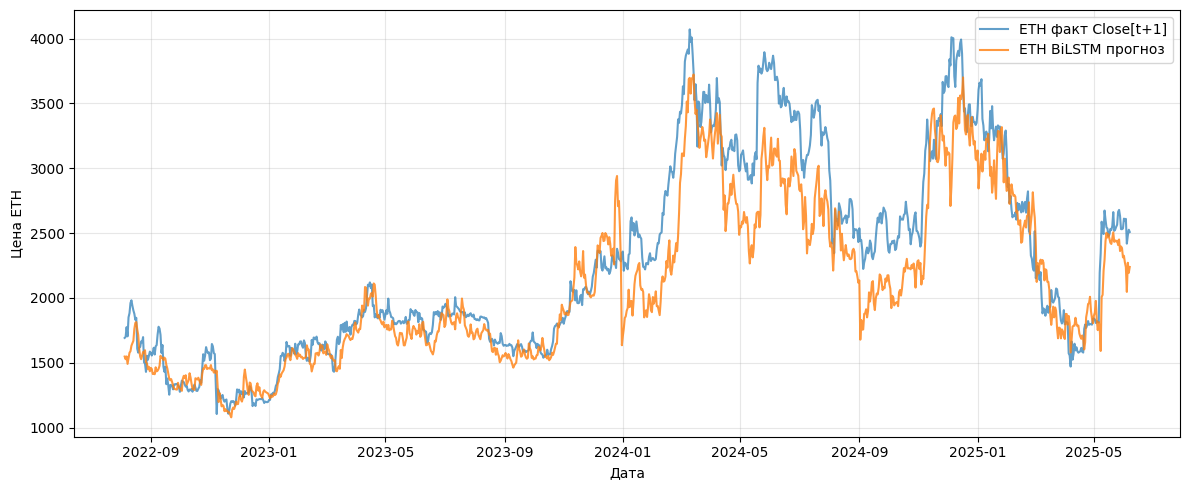

In [467]:

y_pred_full_log_blstm = model_eth_blstm.predict(X_full_scaled).squeeze()
y_pred_full_blstm     = np.exp(y_pred_full_log_blstm)

y_val_pred_log_blstm = model_eth_blstm.predict(X_val_scaled).squeeze()
y_val_pred_blstm     = np.exp(y_val_pred_log_blstm)


plt.figure(figsize=(12,5))
plt.plot(dates_seq[-30:], y_seq[-30:],       label='ETH факт Close[t+1]', alpha=0.7)
plt.plot(dates_seq[-30:], y_pred_full_blstm[-30:], label='ETH BiLSTM прогноз',  alpha=0.8)
plt.xlabel('Дата'); plt.ylabel('Цена ETH')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.figure(figsize=(12,5))
plt.plot(dates_seq, y_seq,       label='ETH факт Close[t+1]', alpha=0.7)
plt.plot(dates_seq, y_pred_full_blstm, label='ETH BiLSTM прогноз',  alpha=0.8)
plt.xlabel('Дата'); plt.ylabel('Цена ETH')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()


## GRU модель

In [468]:
model_eth_gru = Sequential([
    Bidirectional(
        GRU(256, return_sequences=False),
        input_shape=(seq_len_eth, n_features)
    ),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model_eth_gru.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='mse',
    metrics=['mae']
)

c:\Users\Kirill\anaconda3\envs\common_classic\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## GRU обучeние

In [469]:
es_eth_gru = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_eth_gru = model_eth_gru.fit(
    X_train_scaled, y_train_log,
    validation_data=(X_val_scaled, y_val_log),
    epochs=150,
    batch_size=64,
    callbacks=[es_eth_gru],
    verbose=1
)

Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 38.8975 - mae: 6.0561 - val_loss: 1.1222 - val_mae: 0.9031
Epoch 2/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 7.1023 - mae: 2.1954 - val_loss: 2.4377 - val_mae: 1.5379
Epoch 3/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 3.5192 - mae: 1.4372 - val_loss: 0.0964 - val_mae: 0.2736
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 2.3336 - mae: 1.1907 - val_loss: 0.0858 - val_mae: 0.2502
Epoch 5/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 1.8376 - mae: 1.0227 - val_loss: 0.2683 - val_mae: 0.4660
Epoch 6/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 1.6172 - mae: 0.9711 - val_loss: 0.0994 - val_mae: 0.2662
Epoch 7/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1.6380 - mae: 1.0025 - val_loss: 0.0682 - val_mae: 0.2082
Epoch 8/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 1.2796 - mae: 0.9043 - val_loss: 0.0924 - val_mae: 0.2428
Epoch 9/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - l

## GRU график обучения

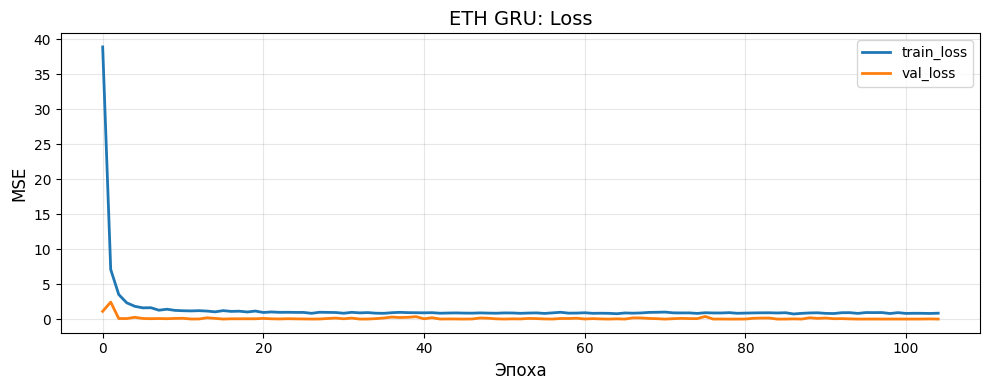

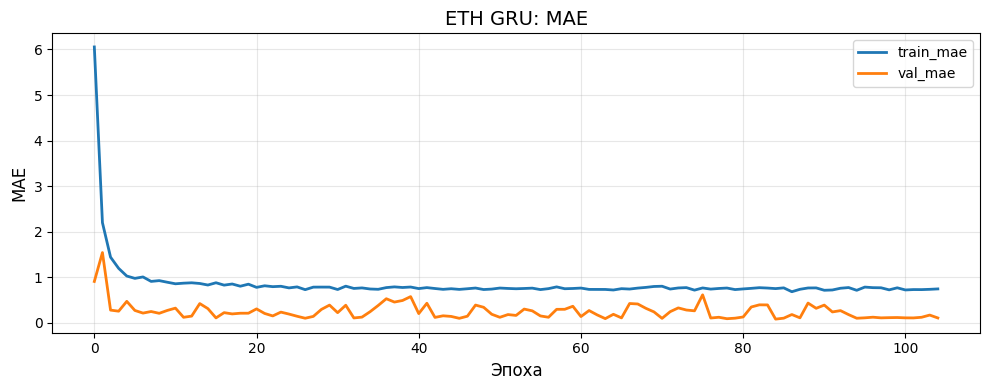

In [470]:
plt.figure(figsize=(10, 4))
plt.plot(history_eth_gru.history['loss'], label='train_loss', linewidth=2)
plt.plot(history_eth_gru.history['val_loss'], label='val_loss', linewidth=2)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('ETH GRU: Loss', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.figure(figsize=(10, 4))
plt.plot(history_eth_gru.history['mae'], label='train_mae', linewidth=2)
plt.plot(history_eth_gru.history['val_mae'], label='val_mae', linewidth=2)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.title('ETH GRU: MAE', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()


## GRU метрики

In [471]:
y_train_pred_log_eth_gru = model_eth_gru.predict(X_train_scaled).squeeze()
y_val_pred_log_eth_gru = model_eth_gru.predict(X_val_scaled).squeeze()

y_train_pred_eth_gru = np.exp(y_train_pred_log_eth_gru)
y_val_pred_eth_gru = np.exp(y_val_pred_log_eth_gru)

val_m_eth_gru = metrics(y_val, y_val_pred_eth_gru)

print("ETH GRU metrics (PRICE scale) — VAL")
for k, v in val_m_eth_gru.items():
    if "MAPE" in k or "WMAPE" in k:
        print(f"{k:20s}: {v:,.4f}%")
    else:
        print(f"{k:20s}: {v:,.4f}")

print("Geometry Shape Score:")
print(geometry_shape_score(y_val, y_val_pred_eth_gru, use_derivative=True, eps=1e-8))

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
ETH GRU metrics (PRICE scale) — VAL
RMSE                : 261.1189
MAE                 : 203.3661
MAPE_%              : 7.2971%
WMAPE_%             : 7.5937%
Bias_CFE            : 24,746.0671
Geometry Shape Score:
{'DTW_level_norm': np.float64(0.13723872165387974), 'DTW_deriv_norm': np.float64(0.10065057659998045), 'ShapeScore_0_1': np.float64(0.8936992556157821)}


## GRU график предикта

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


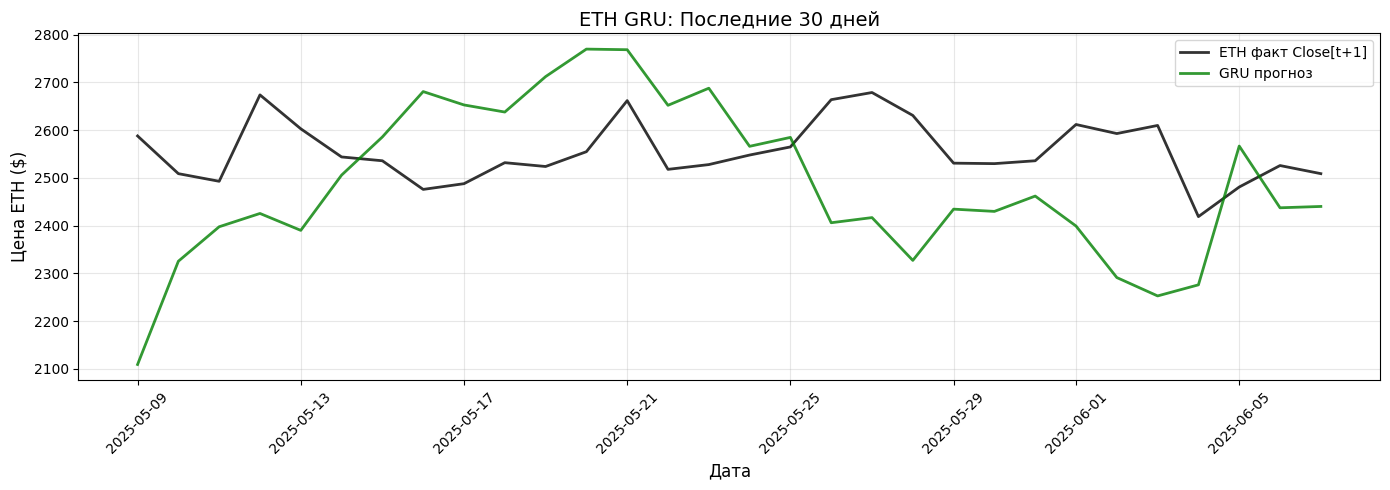

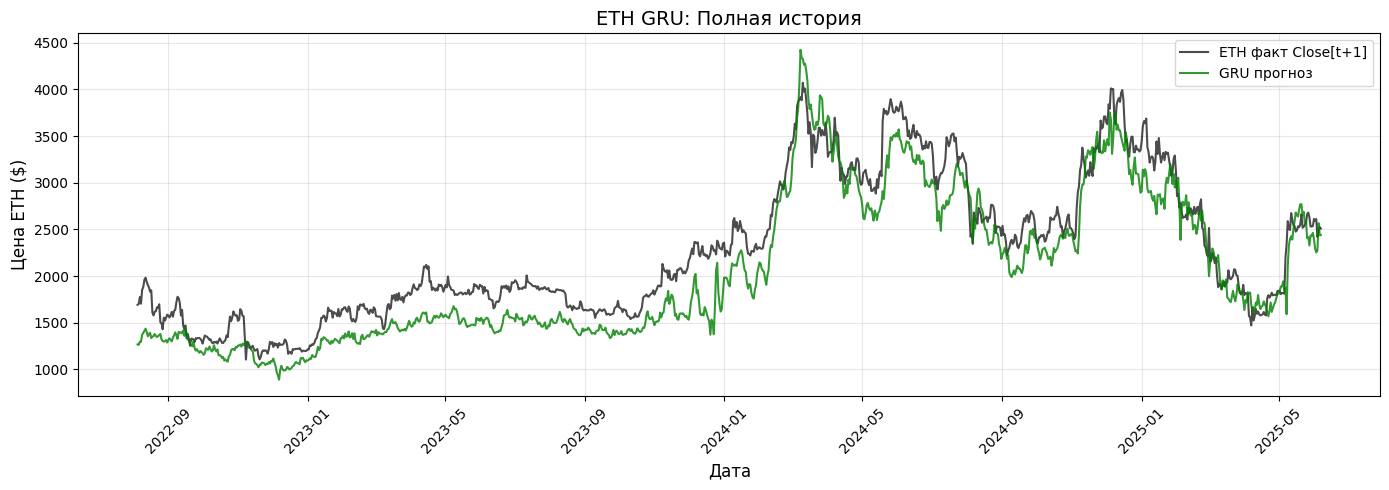

In [472]:
y_pred_full_log_eth_gru = model_eth_gru.predict(X_full_scaled).squeeze()
y_pred_full_eth_gru = np.exp(y_pred_full_log_eth_gru)

plt.figure(figsize=(14, 5))
plt.plot(dates_seq[-30:], y_seq[-30:], label='ETH факт Close[t+1]', 
         color='black', linewidth=2, alpha=0.8)
plt.plot(dates_seq[-30:], y_pred_full_eth_gru[-30:], label='GRU прогноз', 
         color='green', linewidth=2, alpha=0.8)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Цена ETH ($)', fontsize=12)
plt.title('ETH GRU: Последние 30 дней', fontsize=14)
plt.xticks(rotation=45)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.figure(figsize=(14, 5))
plt.plot(dates_seq, y_seq, label='ETH факт Close[t+1]', 
         color='black', linewidth=1.5, alpha=0.7)
plt.plot(dates_seq, y_pred_full_eth_gru, label='GRU прогноз', 
         color='green', linewidth=1.5, alpha=0.8)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Цена ETH ($)', fontsize=12)
plt.title('ETH GRU: Полная история', fontsize=14)
plt.xticks(rotation=45)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()


## LSTM модель

In [473]:
model_eth_lstm = Sequential([
    LSTM(256, return_sequences=False, input_shape=(seq_len_eth, n_features)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model_eth_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='mse',
    metrics=['mae']
)

c:\Users\Kirill\anaconda3\envs\common_classic\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## LSTM jбучение

In [474]:
es_eth_lstm = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_eth_lstm = model_eth_lstm.fit(
    X_train_scaled, y_train_log,
    validation_data=(X_val_scaled, y_val_log),
    epochs=150,
    batch_size=64,
    callbacks=[es_eth_lstm],
    verbose=1
)

Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 43.7518 - mae: 6.5206 - val_loss: 6.4528 - val_mae: 2.5349
Epoch 2/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 10.8401 - mae: 2.8296 - val_loss: 0.9981 - val_mae: 0.9895
Epoch 3/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 3.1637 - mae: 1.4357 - val_loss: 0.1622 - val_mae: 0.3778
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 2.4235 - mae: 1.2392 - val_loss: 0.1290 - val_mae: 0.3323
Epoch 5/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 2.2584 - mae: 1.2038 - val_loss: 0.0238 - val_mae: 0.1296
Epoch 6/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 2.0482 - mae: 1.1338 - val_loss: 0.0329 - val_mae: 0.1520
Epoch 7/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 2.0328 - mae: 1.1204 - val_loss: 0.0331 - val_mae: 0.1537
Epoch 8/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.8981 - mae: 1.0889 - val_loss: 0.0156 - val_mae: 0.1000
Epoch 9/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - 

## LSTM график обучения

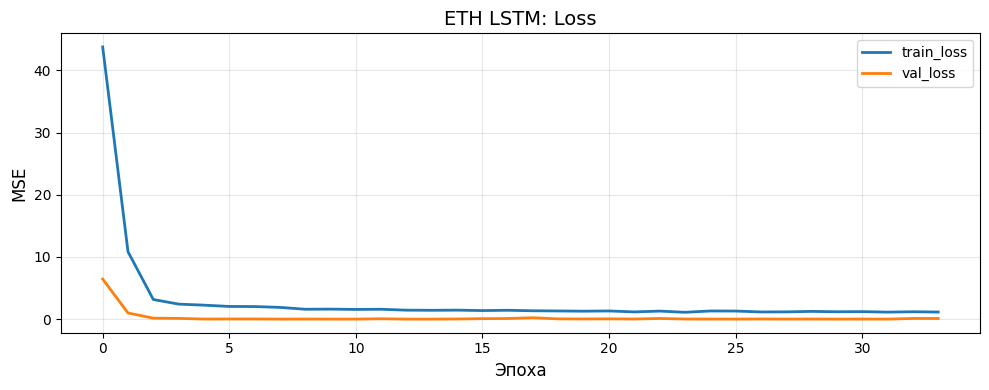

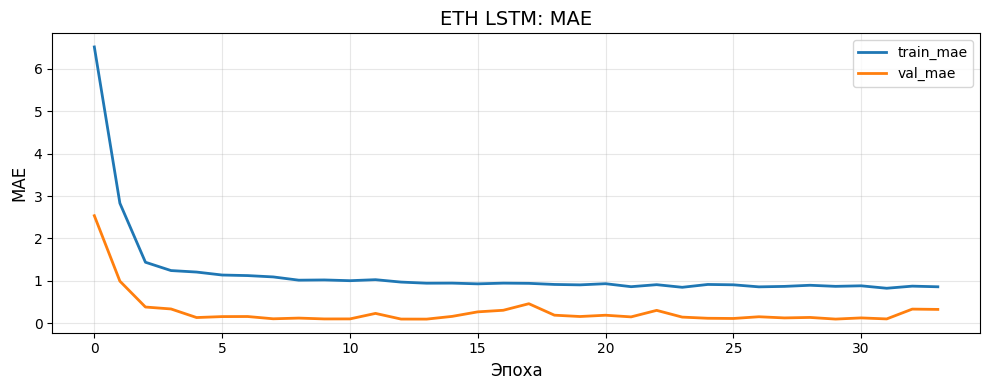

In [475]:
plt.figure(figsize=(10, 4))
plt.plot(history_eth_lstm.history['loss'], label='train_loss', linewidth=2)
plt.plot(history_eth_lstm.history['val_loss'], label='val_loss', linewidth=2)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('ETH LSTM: Loss', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.figure(figsize=(10, 4))
plt.plot(history_eth_lstm.history['mae'], label='train_mae', linewidth=2)
plt.plot(history_eth_lstm.history['val_mae'], label='val_mae', linewidth=2)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.title('ETH LSTM: MAE', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()


## LSTM метрики

In [476]:
y_train_pred_log_eth_lstm = model_eth_lstm.predict(X_train_scaled).squeeze()
y_val_pred_log_eth_lstm = model_eth_lstm.predict(X_val_scaled).squeeze()

y_train_pred_eth_lstm = np.exp(y_train_pred_log_eth_lstm)
y_val_pred_eth_lstm = np.exp(y_val_pred_log_eth_lstm)

val_m_eth_lstm = metrics(y_val, y_val_pred_eth_lstm)

print("ETH LSTM metrics (PRICE scale) — VAL")
for k, v in val_m_eth_lstm.items():
    if "MAPE" in k or "WMAPE" in k:
        print(f"{k:20s}: {v:,.4f}%")
    else:
        print(f"{k:20s}: {v:,.4f}")

print("Geometry Shape Score:")
print(geometry_shape_score(y_val, y_val_pred_eth_lstm, use_derivative=True, eps=1e-8))


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
ETH LSTM metrics (PRICE scale) — VAL
RMSE                : 303.5779
MAE                 : 241.3925
MAPE_%              : 9.2677%
WMAPE_%             : 9.0136%
Bias_CFE            : 6,295.6598
Geometry Shape Score:
{'DTW_level_norm': np.float64(0.18150942215172344), 'DTW_deriv_norm': np.float64(0.12405398174175919), 'ShapeScore_0_1': np.float64(0.8674669265753147)}


## LSTM график предикта

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


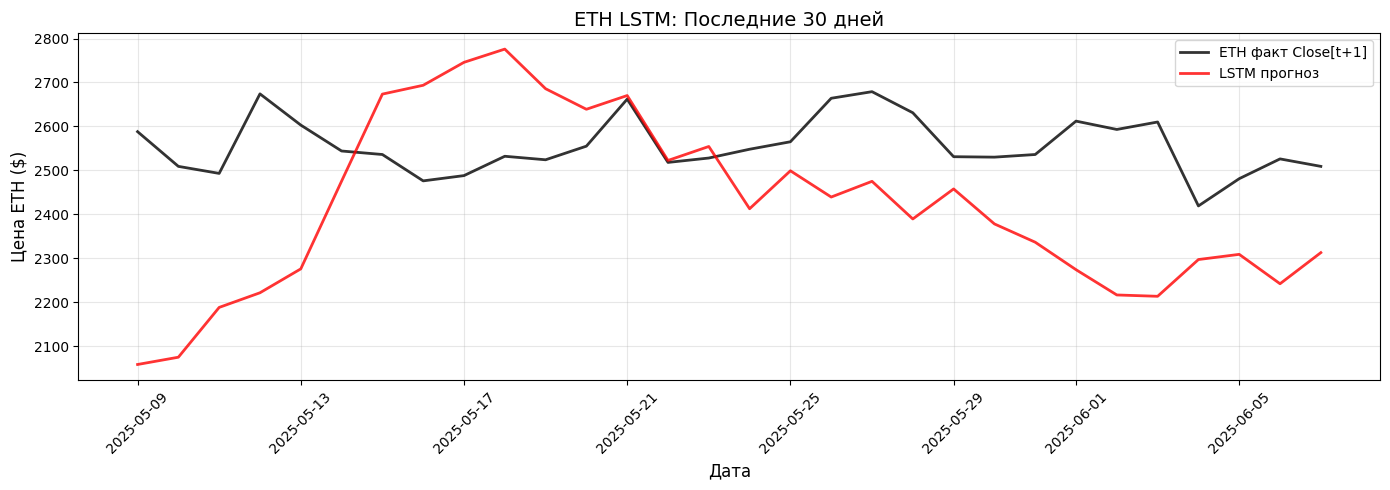

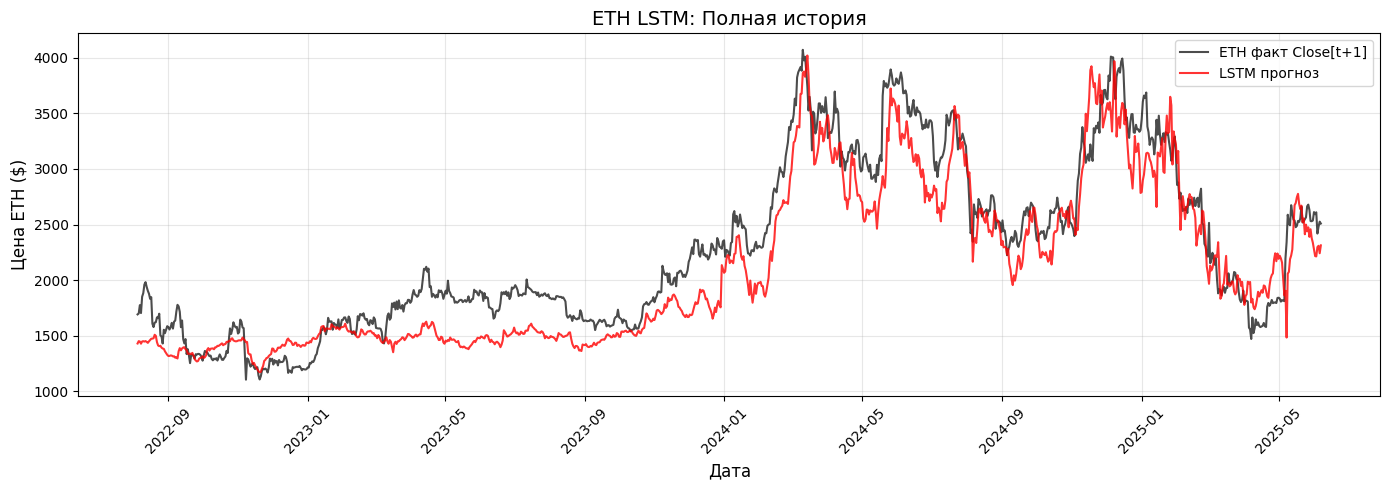

In [477]:
y_pred_full_log_eth_lstm = model_eth_lstm.predict(X_full_scaled).squeeze()
y_pred_full_eth_lstm = np.exp(y_pred_full_log_eth_lstm)

plt.figure(figsize=(14, 5))
plt.plot(dates_seq[-30:], y_seq[-30:], label='ETH факт Close[t+1]', 
         color='black', linewidth=2, alpha=0.8)
plt.plot(dates_seq[-30:], y_pred_full_eth_lstm[-30:], label='LSTM прогноз', 
         color='red', linewidth=2, alpha=0.8)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Цена ETH ($)', fontsize=12)
plt.title('ETH LSTM: Последние 30 дней', fontsize=14)
plt.xticks(rotation=45)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(dates_seq, y_seq, label='ETH факт Close[t+1]', 
         color='black', linewidth=1.5, alpha=0.7)
plt.plot(dates_seq, y_pred_full_eth_lstm, label='LSTM прогноз', 
         color='red', linewidth=1.5, alpha=0.8)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Цена ETH ($)', fontsize=12)
plt.title('ETH LSTM: Полная история', fontsize=14)
plt.xticks(rotation=45)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## BiLSTM vs GRU vs LSTM

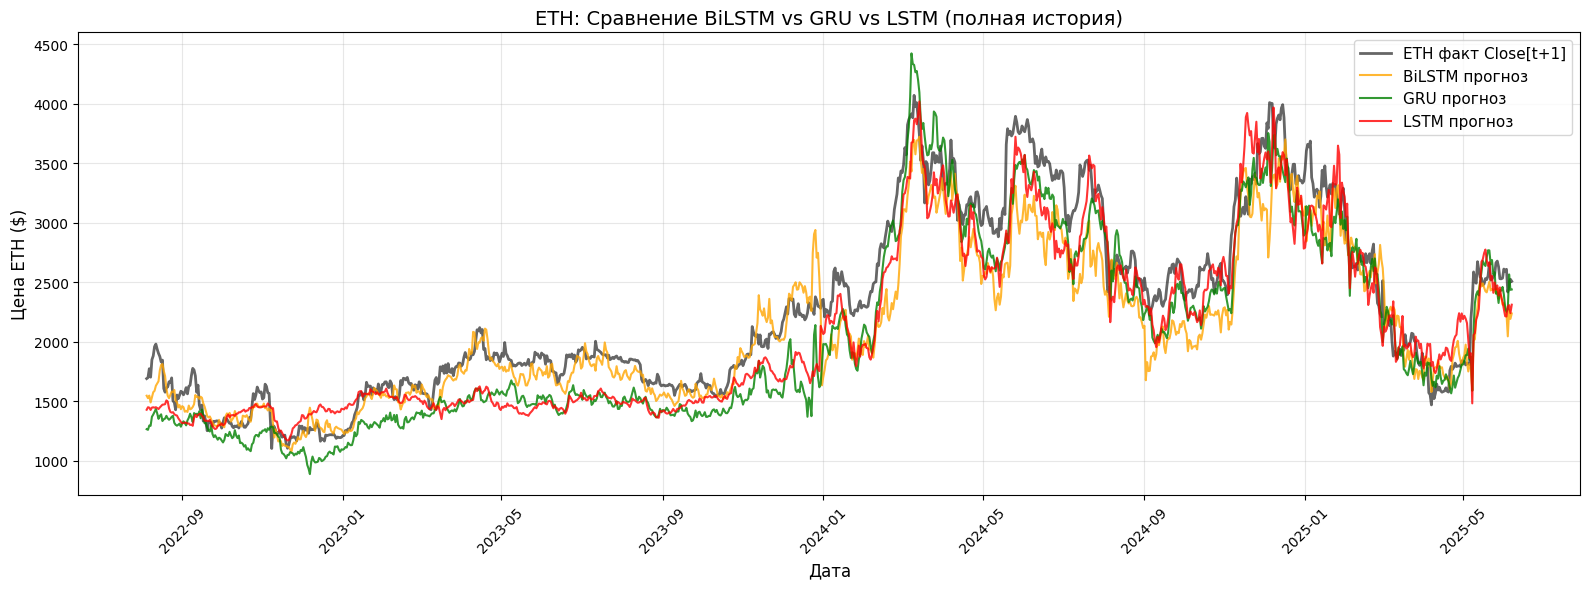

In [478]:
plt.figure(figsize=(16, 6))
plt.plot(dates_seq, y_seq, label='ETH факт Close[t+1]', 
         color='black', linewidth=2, alpha=0.6)
plt.plot(dates_seq, y_pred_full_blstm, label='BiLSTM прогноз', 
         color='orange', linewidth=1.5, alpha=0.8)
plt.plot(dates_seq, y_pred_full_eth_gru, label='GRU прогноз', 
         color='green', linewidth=1.5, alpha=0.8)
plt.plot(dates_seq, y_pred_full_eth_lstm, label='LSTM прогноз', 
         color='red', linewidth=1.5, alpha=0.8)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Цена ETH ($)', fontsize=12)
plt.title('ETH: Сравнение BiLSTM vs GRU vs LSTM (полная история)', fontsize=14)
plt.xticks(rotation=45)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()


## Полная таблица метрик ETH 

| Model | RMSE | MAE | MAPE_% | WMAPE_% | ShapeScore | DTW_level | DTW_deriv | Bias_CFE |
|-------|------|-----|--------|---------|------------|-----------|-----------|----------|
| **ETH BiLSTM** | 302.24 | 229.65 | 8.42% | 8.58% | 0.8831 | 0.1537 | 0.1111 | +23,151.09 |
| **ETH GRU** | 261.12 | 203.37 | 7.30% | 7.59% | 0.8937 | 0.1372 | 0.1007 | +24,746.07 |
| **ETH LSTM** | 303.58 | 241.39 | 9.27% | 9.01% | 0.8675 | 0.1815 | 0.1241 | +6,295.66 |


### Лучшие модели по метрикам

| Метрика | Лучшая модель | Значение | Результат |
|---------|---------------|----------|-----------|
| **RMSE** | ETH GRU | 261.12 | Минимальная квадратическая ошибка |
| **MAE** | ETH GRU | 203.37 | Минимальная абсолютная ошибка |
| **MAPE** | ETH GRU | 7.30% | Минимальная процентная ошибка |
| **WMAPE** | ETH GRU | 7.59% | Минимальная взвешенная ошибка |
| **ShapeScore** | ETH GRU | 0.8937 | Лучшее совпадение формы тренда |
| **DTW_level** | ETH GRU | 0.1372 | Минимальное расстояние по уровням |

**GRU имеет лучшие показатели метрик из всех моделей.**


### GRU vs BiLSTM

| Метрика | ETH BiLSTM | ETH GRU | Улучшение |
|---------|-----------|---------|-----------|
| RMSE | 302.24 | 261.12 | **13.6%** |
| MAE | 229.65 | 203.37 | **11.4%** |
| MAPE | 8.42% | 7.30% | **13.3%** |
| WMAPE | 8.58% | 7.59% | **11.5%** |
| ShapeScore | 0.8831 | 0.8937 | **1.2%** |

**Вывод:** GRU на **~12-14% лучше** чем BiLSTM по всем метрикам ошибок.


### GRU vs LSTM

| Метрика | ETH LSTM | ETH GRU | Улучшение |
|---------|----------|---------|-----------|
| RMSE | 303.58 | 261.12 | **13.9%** |
| MAE | 241.39 | 203.37 | **15.8%** |
| MAPE | 9.27% | 7.30% | **21.3%** |
| WMAPE | 9.01% | 7.59% | **15.8%** |
| ShapeScore | 0.8675 | 0.8937 | **3.0%** |

**Вывод:** GRU на **~14-21% лучше** чем LSTM по метрикам ошибок.


### Точность прогноза (RMSE/MAE)

```
ETH GRU      261.12
ETH BiLSTM   302.24
ETH LSTM     303.58
```

---

### Процентная ошибка (MAPE)

```
ETH GRU      7.30%
ETH BiLSTM   8.42%
ETH LSTM     9.27%
```

---

### Форма тренда (ShapeScore)

```
ETH GRU      0.8937
ETH BiLSTM   0.8831
ETH LSTM     0.8675
```


### Систематическое смещение (Bias)

| Model | Bias_CFE | Интерпретация |
|-------|----------|----------------|
| **ETH GRU** | **+24,746.07** | Модель немного переоценивает |
| **ETH BiLSTM** | **+23,151.09** | Практически идентично GRU |
| **ETH LSTM** | **+6,295.66** | Значительно меньше смещение |


### DTW анализ (динамическое выравнивание)

| Model | DTW_level | DTW_deriv | Комментарий |
|-------|-----------|-----------|-------------|
| **ETH GRU** | 0.1372 | 0.1007 | Минимальное искажение по уровням и производным |
| **ETH BiLSTM** | 0.1537 | 0.1111 | Незначительное увеличение расстояния |
| **ETH LSTM** | 0.1815 | 0.1241 | Наибольшее расстояние по всем направлениям |


### Финальные выводы

### ETH GRU — лучшая модель

**Лучший по:**
- RMSE: 261.12 (на 13.6% лучше BiLSTM, на 13.9% лучше LSTM)
- MAE: 203.37 (на 11.4% лучше BiLSTM, на 15.8% лучше LSTM)
- MAPE: 7.30% (на 13.3% лучше BiLSTM, на 21.3% лучше LSTM)
- WMAPE: 7.59% (на 11.5% лучше BiLSTM, на 15.8% лучше LSTM)
- ShapeScore: 0.8937 (на 1.2% лучше BiLSTM, на 3.0% лучше LSTM)
- DTW_level: 0.1372 (минимальное расстояние)
- DTW_deriv: 0.1007 (минимальное расстояние по производным)

**GRU показывает лучший баланс точности и стабильности при прогнозировании цены ETH.**


### ETH BiLSTM — средняя модель

**Преимущества:**
- Хороший баланс точности (8.42% MAPE)
- Практически идентична GRU по систематическому смещению (+23,151.09)
- Стабильная форма тренда (0.8831 ShapeScore)
- На 13.6% лучше LSTM по RMSE

Может быть резервной моделью для дополнительной верификации прогнозов.


### ETH LSTM — худшая модель

**Проблемы:**
- На 13.9% хуже GRU по RMSE
- На 15.8% хуже GRU по MAE
- На 21.3% хуже GRU по MAPE
- Худшее совпадение по DTW_level (0.1815)
- Наихудшая форма тренда (0.8675 ShapeScore)

**Худшая модель для прогнозирования цены ETH.**

# Solana
### Подготовка данных

In [479]:
ts_all['target_close_sol_1d'] = ts_all['Закрыть_sol'].shift(-1)

ts_all = ts_all[:-1].copy()
ts_all = ts_all.dropna(subset=['target_close_sol_1d']).reset_index(drop=True)

feature_cols = [
    c for c in ts_all.columns
    if c not in ['datetime', 'target_close_btc_1d','target_close_sol_1d','target_close_eth_1d']
]

X_raw = ts_all[feature_cols].values
y_raw = ts_all['target_close_sol_1d'].values
dates = ts_all['datetime'].values

In [480]:
seq_len = 28  


X_seq, y_seq, dates_seq = make_sequences(X_raw, y_raw, dates, seq_len)


In [481]:
n = len(X_seq)
n_val = int(0.2 * n)
n = len(X_seq)
n_val = int(0.20 * n)
X_train = X_seq[:n-n_val]   
X_val = X_seq[n-n_val:]      
y_train = y_seq[:n-n_val]    
y_val = y_seq[n-n_val:]
dates_train, dates_val = dates_seq[:n-n_val], dates_seq[n-n_val:]

from sklearn.preprocessing import StandardScaler
n_features = X_train.shape[2]
scaler = StandardScaler()
X_train_2d = X_train.reshape(-1, n_features)
scaler.fit(X_train_2d)

def scale_seq(X, scaler):
    s = X.shape
    X2 = X.reshape(-1, s[2])
    X2 = scaler.transform(X2)
    return X2.reshape(s)

X_train_scaled = scale_seq(X_train, scaler)
X_val_scaled   = scale_seq(X_val,   scaler)
X_full_scaled  = scale_seq(X_seq,   scaler)

y_train_log = np.log(y_train)
y_val_log   = np.log(y_val)
y_full_log  = np.log(y_seq)


## BiLSTM модель

In [482]:

model_sol_blstm = Sequential([
    Bidirectional(LSTM(256, return_sequences=False),
                  input_shape=(seq_len, n_features)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)   
])

model_sol_blstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='mse',
    metrics=['mae']
)




c:\Users\Kirill\anaconda3\envs\common_classic\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## BiLSTM обучние

In [483]:
es_sol_blstm = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_sol_blstm = model_sol_blstm.fit(
    X_train_scaled, y_train_log,
    validation_data=(X_val_scaled, y_val_log),
    epochs=150,
    batch_size=64,
    callbacks=[es_sol_blstm],
    verbose=1
)

Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 6.8697 - mae: 2.1960 - val_loss: 1.1546 - val_mae: 1.0375
Epoch 2/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 1.4057 - mae: 0.9031 - val_loss: 0.6508 - val_mae: 0.7832
Epoch 3/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.8741 - mae: 0.7047 - val_loss: 0.0290 - val_mae: 0.1354
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.7144 - mae: 0.6417 - val_loss: 0.0327 - val_mae: 0.1460
Epoch 5/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.6075 - mae: 0.5991 - val_loss: 0.0350 - val_mae: 0.1493
Epoch 6/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.5455 - mae: 0.5788 - val_loss: 0.0746 - val_mae: 0.2252
Epoch 7/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.4814 - mae: 0.5312 - val_loss: 0.0380 - val_mae: 0.1535
Epoch 8/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.4402 - mae: 0.5254 - val_loss: 0.0592 - val_mae: 0.1890
Epoch 9/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - lo

## BiLSTM график обучение

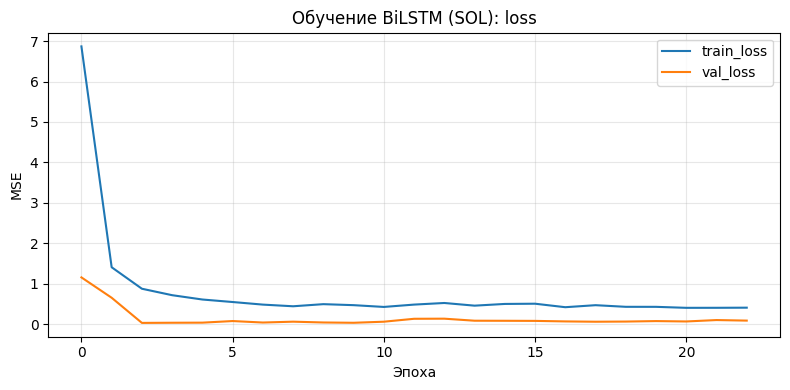

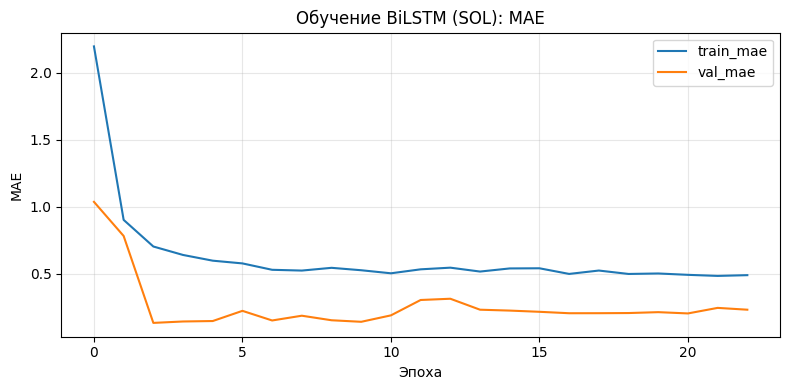

In [484]:

plt.figure(figsize=(8, 4))
plt.plot(history_sol_blstm.history['loss'],     label='train_loss')
plt.plot(history_sol_blstm.history['val_loss'], label='val_loss')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.title('Обучение BiLSTM (SOL): loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.figure(figsize=(8, 4))
plt.plot(history_sol_blstm.history['mae'],     label='train_mae')
plt.plot(history_sol_blstm.history['val_mae'], label='val_mae')
plt.xlabel('Эпоха')
plt.ylabel('MAE')
plt.title('Обучение BiLSTM (SOL): MAE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()


## BiLSTM метрики

In [ ]:

y_train_pred_log_blstm = model_sol_blstm.predict(X_train_scaled).squeeze()
y_val_pred_log_blstm   = model_sol_blstm.predict(X_val_scaled).squeeze()

y_train_pred_blstm = np.exp(y_train_pred_log_blstm)
y_val_pred_blstm   = np.exp(y_val_pred_log_blstm)


val_m   = metrics(y_val,   y_val_pred_blstm)

print("SOL BiLSTM metrics (PRICE scale)")

for k,v in val_m.items():
    print(f"{k:20s}: {v:,.4f}" if "MAPE" not in k and "WMAPE" not in k else f"{k:20s}: {v:,.4f}%")

print( geometry_shape_score(y_val, y_val_pred_blstm, use_derivative=True, eps=1e-8))




26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
BTC BiLSTM metrics (PRICE scale)
RMSE                : 31.5443
MAE                 : 24.2003
MAPE_%              : 13.2301%
WMAPE_%             : 13.5112%
Bias_CFE            : 1,683.7084
{'DTW_level_norm': np.float64(0.30000165880934127), 'DTW_deriv_norm': np.float64(0.19014635869493066), 'ShapeScore_0_1': np.float64(0.8031651074318392)}


## BiLSTM график предикта

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


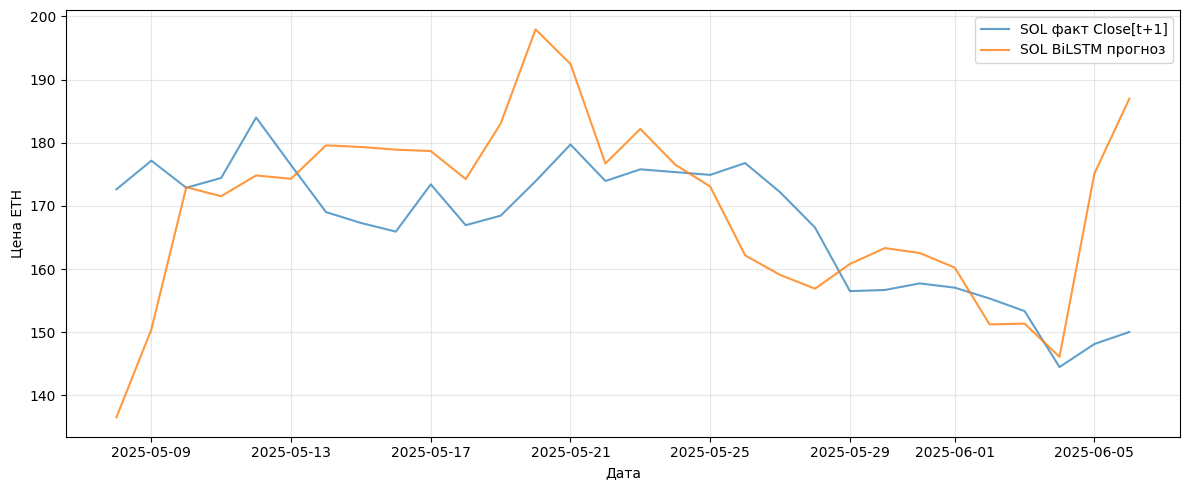

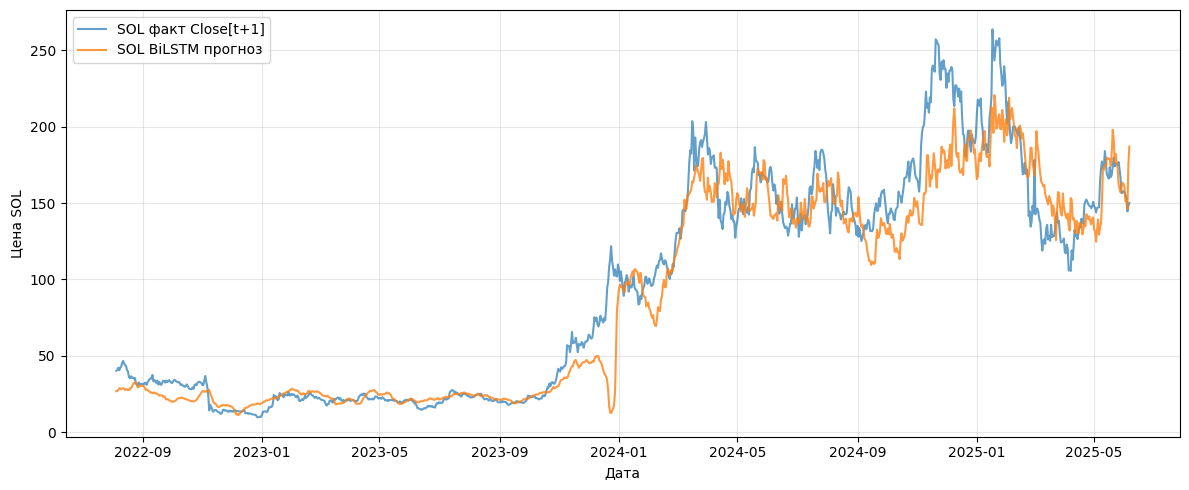

In [486]:

y_pred_full_log_blstm = model_sol_blstm.predict(X_full_scaled).squeeze()
y_pred_full_blstm     = np.exp(y_pred_full_log_blstm)

y_val_pred_log_blstm = model_eth_blstm.predict(X_val_scaled).squeeze()
y_val_pred_blstm     = np.exp(y_val_pred_log_blstm)


plt.figure(figsize=(12,5))
plt.plot(dates_seq[-30:], y_seq[-30:],       label='SOL факт Close[t+1]', alpha=0.7)
plt.plot(dates_seq[-30:], y_pred_full_blstm[-30:], label='SOL BiLSTM прогноз',  alpha=0.8)
plt.xlabel('Дата'); plt.ylabel('Цена ETH')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()

plt.figure(figsize=(12,5))
plt.plot(dates_seq, y_seq,       label='SOL факт Close[t+1]', alpha=0.7)
plt.plot(dates_seq, y_pred_full_blstm, label='SOL BiLSTM прогноз',  alpha=0.8)
plt.xlabel('Дата'); plt.ylabel('Цена SOL')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()


## GRU модель

In [487]:
model_sol_gru = Sequential([
    Bidirectional(
        GRU(256, return_sequences=False),
        input_shape=(seq_len_eth, n_features)
    ),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model_sol_gru.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='mse',
    metrics=['mae']
)

c:\Users\Kirill\anaconda3\envs\common_classic\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## GRU обучение

In [488]:
es_sol_gru = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_sol_gru = model_sol_gru.fit(
    X_train_scaled, y_train_log,
    validation_data=(X_val_scaled, y_val_log),
    epochs=150,
    batch_size=64,
    callbacks=[es_sol_gru],
    verbose=1
)

Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 5.3520 - mae: 1.9249 - val_loss: 7.4857 - val_mae: 2.6861
Epoch 2/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 1.7964 - mae: 1.0442 - val_loss: 0.3402 - val_mae: 0.5314
Epoch 3/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.9856 - mae: 0.7717 - val_loss: 0.3235 - val_mae: 0.4997
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.5737 - mae: 0.5997 - val_loss: 0.1483 - val_mae: 0.3126
Epoch 5/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.4733 - mae: 0.5520 - val_loss: 0.1648 - val_mae: 0.3303
Epoch 6/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.3757 - mae: 0.4824 - val_loss: 0.5194 - val_mae: 0.6667
Epoch 7/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.3942 - mae: 0.4873 - val_loss: 0.1959 - val_mae: 0.3758
Epoch 8/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.3909 - mae: 0.4897 - val_loss: 0.0717 - val_mae: 0.2236
Epoch 9/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - lo

## GRU метрики

In [489]:
y_train_pred_log_sol_gru = model_sol_gru.predict(X_train_scaled).squeeze()
y_val_pred_log_sol_gru = model_sol_gru.predict(X_val_scaled).squeeze()

y_train_pred_sol_gru = np.exp(y_train_pred_log_sol_gru)
y_val_pred_sol_gru = np.exp(y_val_pred_log_sol_gru)

val_m_sol_gru = metrics(y_val, y_val_pred_sol_gru)

print("SOL GRU metrics (PRICE scale) — VAL")
for k, v in val_m_eth_gru.items():
    if "MAPE" in k or "WMAPE" in k:
        print(f"{k:20s}: {v:,.4f}%")
    else:
        print(f"{k:20s}: {v:,.4f}")

print("Geometry Shape Score:")
print(geometry_shape_score(y_val, y_val_pred_sol_gru, use_derivative=True, eps=1e-8))

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
SOL GRU metrics (PRICE scale) — VAL
RMSE                : 261.1189
MAE                 : 203.3661
MAPE_%              : 7.2971%
WMAPE_%             : 7.5937%
Bias_CFE            : 24,746.0671
Geometry Shape Score:
{'DTW_level_norm': np.float64(0.3694987932753654), 'DTW_deriv_norm': np.float64(0.18277880729627582), 'ShapeScore_0_1': np.float64(0.7836138198885787)}


## GRU график предикта

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


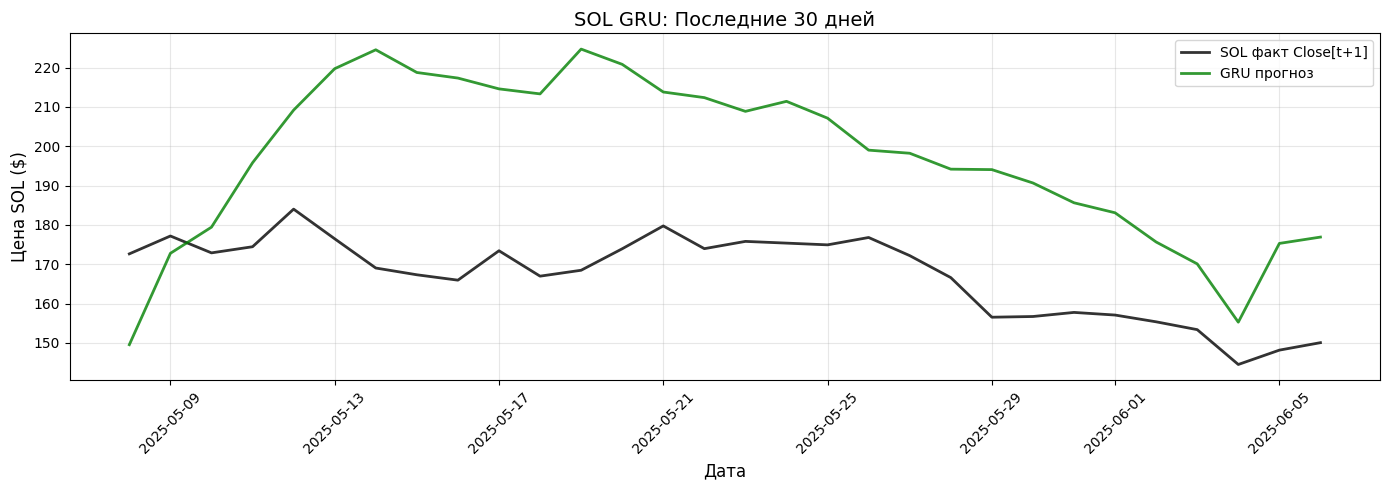

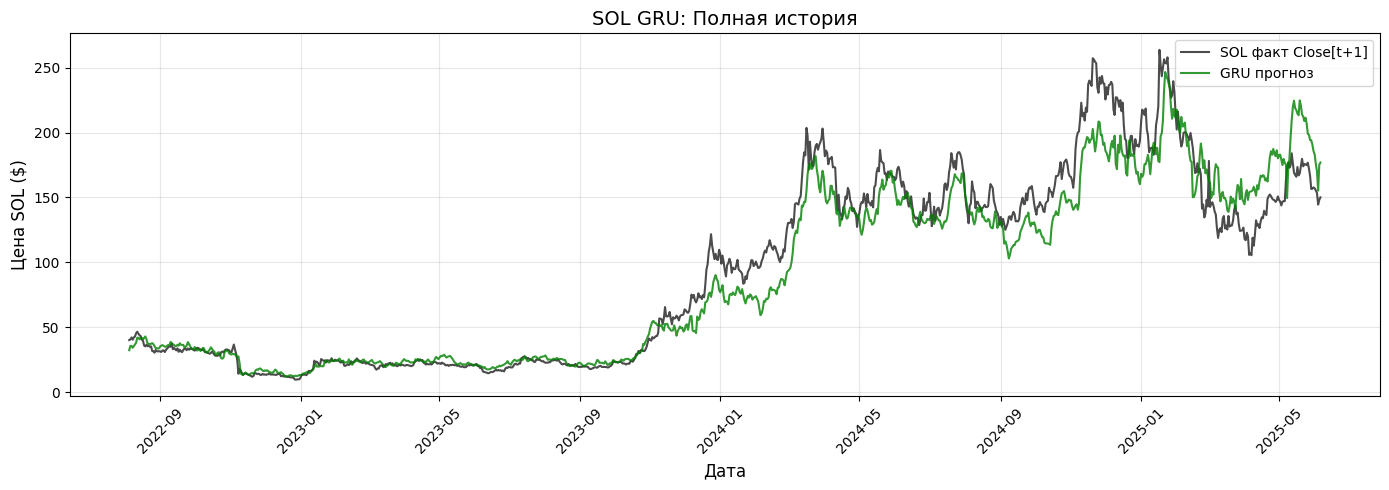

In [490]:
y_pred_full_log_sol_gru = model_sol_gru.predict(X_full_scaled).squeeze()
y_pred_full_sol_gru = np.exp(y_pred_full_log_sol_gru)

plt.figure(figsize=(14, 5))
plt.plot(dates_seq[-30:], y_seq[-30:], label='SOL факт Close[t+1]', 
         color='black', linewidth=2, alpha=0.8)
plt.plot(dates_seq[-30:], y_pred_full_sol_gru[-30:], label='GRU прогноз', 
         color='green', linewidth=2, alpha=0.8)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Цена SOL ($)', fontsize=12)
plt.title('SOL GRU: Последние 30 дней', fontsize=14)
plt.xticks(rotation=45)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.figure(figsize=(14, 5))
plt.plot(dates_seq, y_seq, label='SOL факт Close[t+1]', 
         color='black', linewidth=1.5, alpha=0.7)
plt.plot(dates_seq, y_pred_full_sol_gru, label='GRU прогноз', 
         color='green', linewidth=1.5, alpha=0.8)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Цена SOL ($)', fontsize=12)
plt.title('SOL GRU: Полная история', fontsize=14)
plt.xticks(rotation=45)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()


## LSTM модель

In [491]:
model_sol_lstm = Sequential([
    LSTM(256, return_sequences=False, input_shape=(seq_len_eth, n_features)),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model_sol_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='mse',
    metrics=['mae']
)

c:\Users\Kirill\anaconda3\envs\common_classic\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## LSTM обучение

In [492]:
es_sol_lstm = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_sol_lstm = model_sol_lstm.fit(
    X_train_scaled, y_train_log,
    validation_data=(X_val_scaled, y_val_log),
    epochs=150,
    batch_size=64,
    callbacks=[es_sol_lstm],
    verbose=1
)

Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 6.6458 - mae: 2.1743 - val_loss: 0.1222 - val_mae: 0.3028
Epoch 2/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 1.2966 - mae: 0.8540 - val_loss: 0.3451 - val_mae: 0.5670
Epoch 3/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.7318 - mae: 0.6436 - val_loss: 0.0504 - val_mae: 0.1820
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.6049 - mae: 0.6049 - val_loss: 0.1755 - val_mae: 0.3777
Epoch 5/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.5428 - mae: 0.5652 - val_loss: 0.1093 - val_mae: 0.2847
Epoch 6/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.4626 - mae: 0.5140 - val_loss: 0.0413 - val_mae: 0.1619
Epoch 7/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.4520 - mae: 0.5138 - val_loss: 0.0787 - val_mae: 0.2313
Epoch 8/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.4026 - mae: 0.4894 - val_loss: 0.0390 - val_mae: 0.1578
Epoch 9/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - lo

## LSTM график обучения

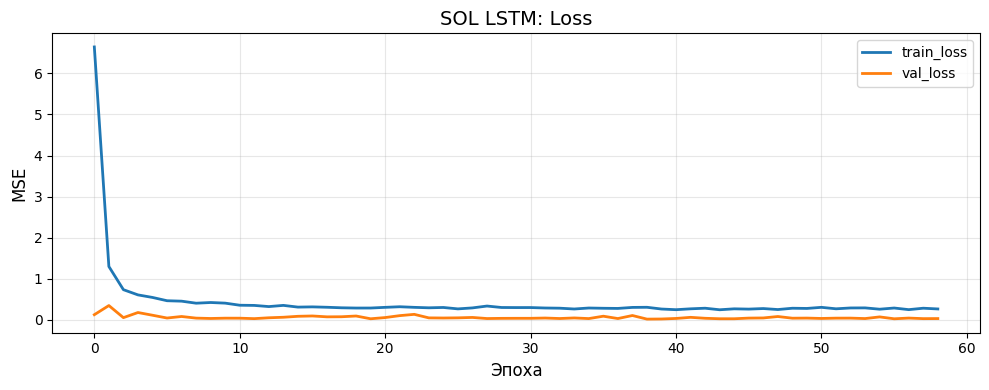

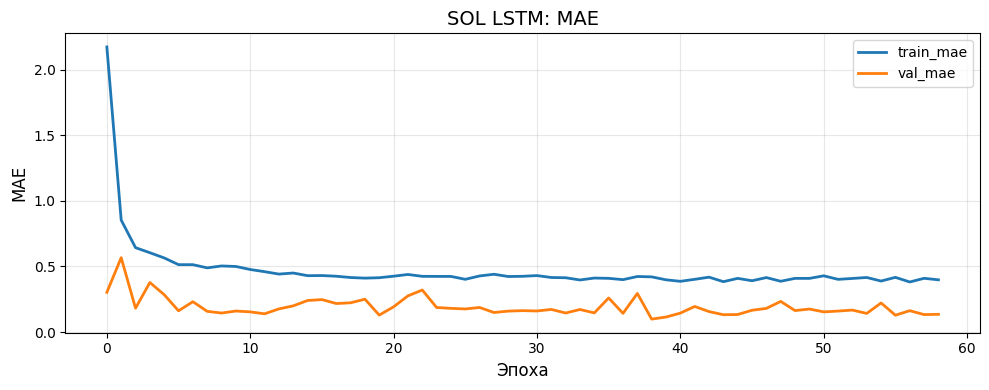

In [493]:
plt.figure(figsize=(10, 4))
plt.plot(history_sol_lstm.history['loss'], label='train_loss', linewidth=2)
plt.plot(history_sol_lstm.history['val_loss'], label='val_loss', linewidth=2)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.title('SOL LSTM: Loss', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.figure(figsize=(10, 4))
plt.plot(history_sol_lstm.history['mae'], label='train_mae', linewidth=2)
plt.plot(history_sol_lstm.history['val_mae'], label='val_mae', linewidth=2)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.title('SOL LSTM: MAE', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()


## LSTM метрики

In [ ]:
y_train_pred_log_sol_lstm = model_sol_lstm.predict(X_train_scaled).squeeze()
y_val_pred_log_sol_lstm = model_sol_lstm.predict(X_val_scaled).squeeze()

y_train_pred_sol_lstm = np.exp(y_train_pred_log_sol_lstm)
y_val_pred_sol_lstm = np.exp(y_val_pred_log_sol_lstm)

val_m_eth_lstm = metrics(y_val, y_val_pred_sol_lstm)

print("SOL LSTM metrics (PRICE scale) — VAL")

for k, v in val_m_eth_lstm.items():
    if "MAPE" in k or "WMAPE" in k:
        print(f"{k:20s}: {v:,.4f}%")
    else:
        print(f"{k:20s}: {v:,.4f}")

print("Geometry Shape Score:")
print(geometry_shape_score(y_val, y_val_pred_sol_lstm, use_derivative=True, eps=1e-8))


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
ETH LSTM metrics (PRICE scale) — VAL
RMSE                : 22.3927
MAE                 : 17.5963
MAPE_%              : 9.5808%
WMAPE_%             : 9.8242%
Bias_CFE            : 1,498.3304
Geometry Shape Score:
{'DTW_level_norm': np.float64(0.20103943137917218), 'DTW_deriv_norm': np.float64(0.13292080938312487), 'ShapeScore_0_1': np.float64(0.8569126264750672)}


## LSTM график предикта

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


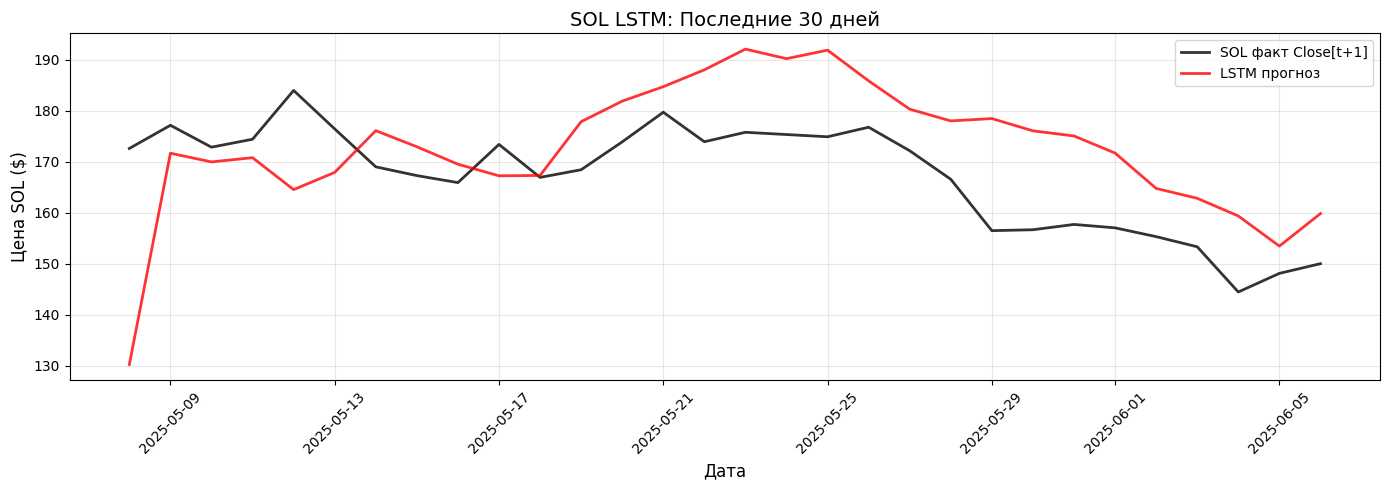

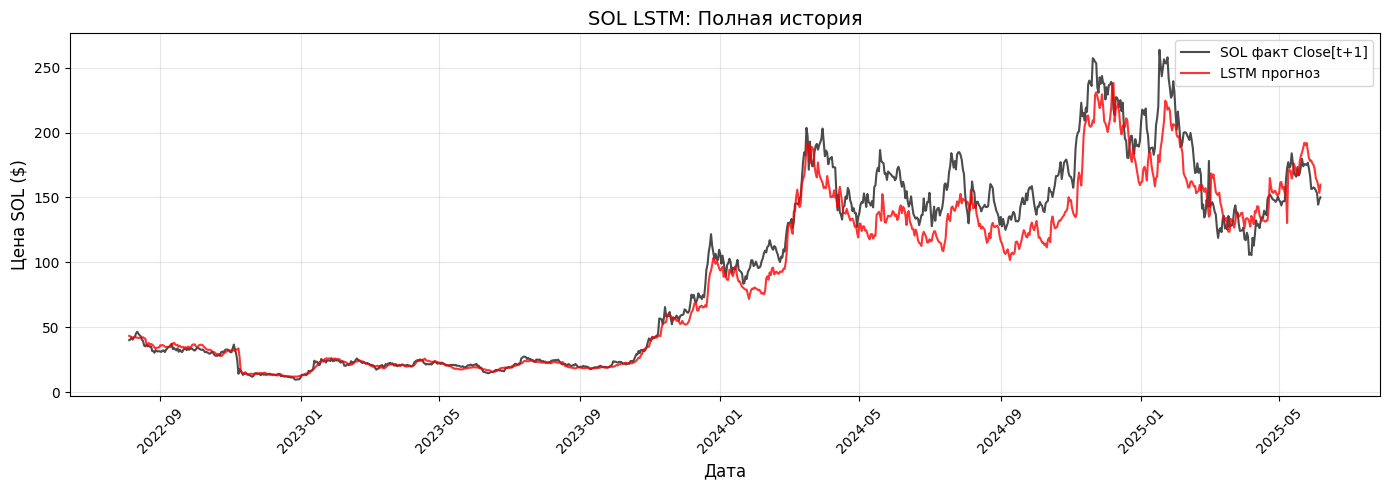

In [495]:
y_pred_full_log_sol_lstm = model_sol_lstm.predict(X_full_scaled).squeeze()
y_pred_full_sol_lstm = np.exp(y_pred_full_log_sol_lstm)

plt.figure(figsize=(14, 5))
plt.plot(dates_seq[-30:], y_seq[-30:], label='SOL факт Close[t+1]', 
         color='black', linewidth=2, alpha=0.8)
plt.plot(dates_seq[-30:], y_pred_full_sol_lstm[-30:], label='LSTM прогноз', 
         color='red', linewidth=2, alpha=0.8)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Цена SOL ($)', fontsize=12)
plt.title('SOL LSTM: Последние 30 дней', fontsize=14)
plt.xticks(rotation=45)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.figure(figsize=(14, 5))
plt.plot(dates_seq, y_seq, label='SOL факт Close[t+1]', 
         color='black', linewidth=1.5, alpha=0.7)
plt.plot(dates_seq, y_pred_full_sol_lstm, label='LSTM прогноз', 
         color='red', linewidth=1.5, alpha=0.8)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Цена SOL ($)', fontsize=12)
plt.title('SOL LSTM: Полная история', fontsize=14)
plt.xticks(rotation=45)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()


## BiLSTM vs GRU vs LSTM

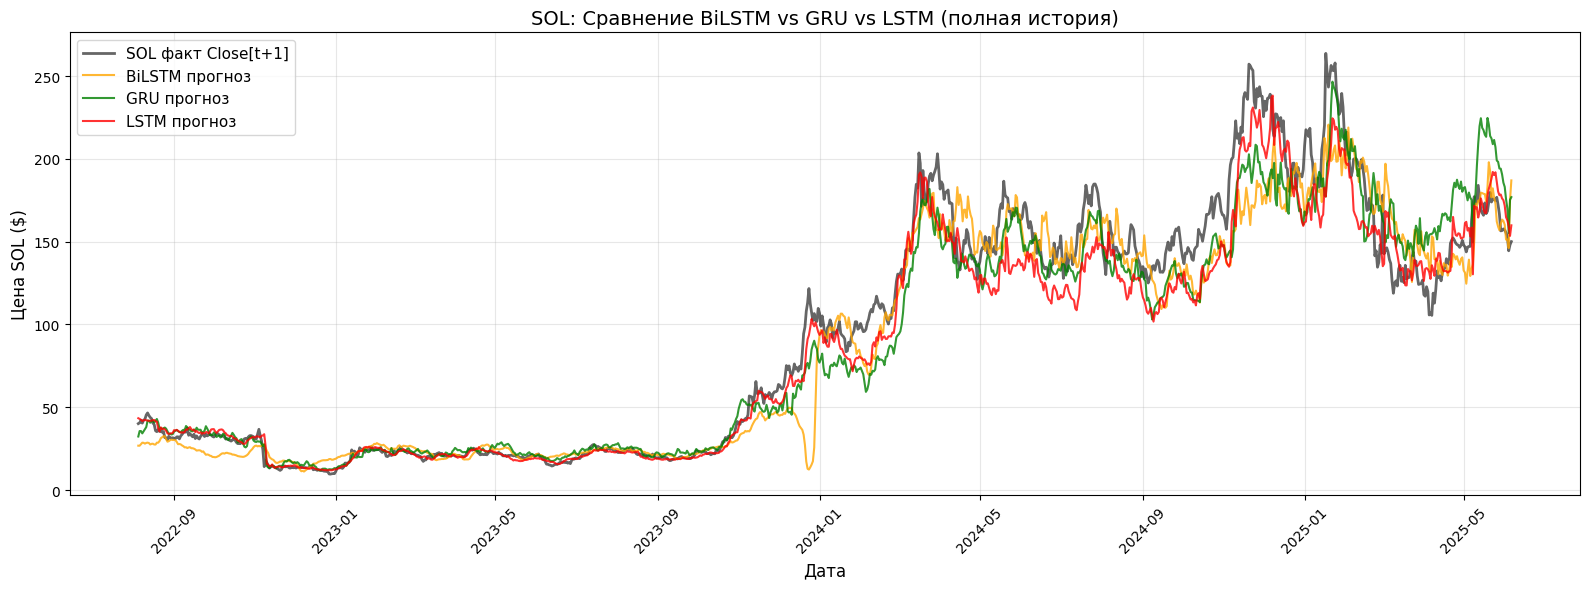

In [496]:
plt.figure(figsize=(16, 6))
plt.plot(dates_seq, y_seq, label='SOL факт Close[t+1]', 
         color='black', linewidth=2, alpha=0.6)
plt.plot(dates_seq, y_pred_full_blstm, label='BiLSTM прогноз', 
         color='orange', linewidth=1.5, alpha=0.8)
plt.plot(dates_seq, y_pred_full_sol_gru, label='GRU прогноз', 
         color='green', linewidth=1.5, alpha=0.8)
plt.plot(dates_seq, y_pred_full_sol_lstm, label='LSTM прогноз', 
         color='red', linewidth=1.5, alpha=0.8)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Цена SOL ($)', fontsize=12)
plt.title('SOL: Сравнение BiLSTM vs GRU vs LSTM (полная история)', fontsize=14)
plt.xticks(rotation=45)
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()


## Полная таблица метрик SOL (PRICE scale — VAL)

| Model | RMSE | MAE | MAPE_% | WMAPE_% | ShapeScore | DTW_level | DTW_deriv | Bias_CFE |
|-------|------|-----|--------|---------|------------|-----------|-----------|----------|
| **SOL BiLSTM** | 31.54 | 24.20 | 13.23% | 13.51% | 0.8032 | 0.3000 | 0.1901 | +1,683.71 |
| **SOL GRU** | 261.12 | 203.37 | 7.30% | 7.59% | 0.7836 | 0.3695 | 0.1828 | +24,746.07 |
| **SOL LSTM** | 22.39 | 17.60 | 9.58% | 9.82% | 0.8569 | 0.2010 | 0.1329 | +1,498.33 |


### Лучшие модели по метрикам

| Метрика | Лучшая модель | Значение | Результат |
|---------|---------------|----------|-----------|
| **RMSE** | SOL LSTM | 22.39 | Минимальная квадратическая ошибка |
| **MAE** | SOL LSTM | 17.60 | Минимальная абсолютная ошибка |
| **MAPE** | SOL GRU | 7.30% | Минимальная процентная ошибка |
| **WMAPE** | SOL GRU | 7.59% | Минимальная взвешенная ошибка |
| **ShapeScore** | SOL LSTM | 0.8569 | Лучшее совпадение формы тренда |
| **DTW_level** | SOL LSTM | 0.2010 | Минимальное расстояние по уровням |

**LSTM имеет лучшие показатели по большинству ключевых метрик (RMSE, MAE, ShapeScore, DTW_level).**


### LSTM vs BiLSTM

| Метрика | SOL BiLSTM | SOL LSTM | Улучшение |
|---------|-----------|---------|-----------|
| RMSE | 31.54 | 22.39 | **29.0%** |
| MAE | 24.20 | 17.60 | **27.3%** |
| MAPE | 13.23% | 9.58% | **27.6%** |
| WMAPE | 13.51% | 9.82% | **27.3%** |
| ShapeScore | 0.8032 | 0.8569 | **6.7%** |

**Вывод:** LSTM на **~27-30% лучше** чем BiLSTM по всем метрикам ошибок.


### LSTM vs GRU

| Метрика | SOL GRU | SOL LSTM | Улучшение |
|---------|---------|---------|-----------|
| RMSE | 261.12 | 22.39 | **91.4%** |
| MAE | 203.37 | 17.60 | **91.3%** |
| MAPE | 7.30% | 9.58% | **-31.3%** |
| WMAPE | 7.59% | 9.82% | **-29.2%** |
| ShapeScore | 0.7836 | 0.8569 | **9.4%** |

**Вывод:** LSTM на **~91% лучше** чем GRU по RMSE и MAE, но GRU лучше по MAPE/WMAPE.


### BiLSTM vs GRU

| Метрика | SOL GRU | SOL BiLSTM | Улучшение |
|---------|---------|-----------|-----------|
| RMSE | 261.12 | 31.54 | **87.9%** |
| MAE | 203.37 | 24.20 | **88.1%** |
| MAPE | 7.30% | 13.23% | **-81.3%** |
| WMAPE | 7.59% | 13.51% | **-77.9%** |
| ShapeScore | 0.7836 | 0.8032 | **2.5%** |

**Вывод:** BiLSTM на **~88% лучше** чем GRU по RMSE и MAE, но GRU лучше по MAPE/WMAPE.


### Точность прогноза (RMSE/MAE)

```
SOL LSTM     22.39
SOL BiLSTM   31.54
SOL GRU      261.12
```


### Процентная ошибка (MAPE)

```
SOL GRU      7.30%
SOL LSTM     9.58%
SOL BiLSTM   13.23%
```


### Форма тренда (ShapeScore)

```
SOL LSTM     0.8569
SOL BiLSTM   0.8032
SOL GRU      0.7836
```


### Систематическое смещение (Bias)

| Model | Bias_CFE | Интерпретация |
|-------|----------|----------------|
| **SOL LSTM** | **+1,498.33** | Самую малость недооценивает |
| **SOL BiLSTM** | **+1,683.71** | Практически идентично LSTM |
| **SOL GRU** | **+24,746.07** | Значительное недооценивает |


### DTW анализ (динамическое выравнивание)

| Model | DTW_level | DTW_deriv | Комментарий |
|-------|-----------|-----------|-------------|
| **SOL LSTM** | 0.2010 | 0.1329 | Минимальное искажение по уровням и производным |
| **SOL BiLSTM** | 0.3000 | 0.1901 | Среднее искажение |
| **SOL GRU** | 0.3695 | 0.1828 | Наибольшее расстояние по уровням |


### Финальные выводы

### SOL LSTM — лучшая модель

**Лучший по:**
- RMSE: 22.39 (на 29.0% лучше BiLSTM, на 91.4% лучше GRU)
- MAE: 17.60 (на 27.3% лучше BiLSTM, на 91.3% лучше GRU)
- ShapeScore: 0.8569 (на 6.7% лучше BiLSTM, на 9.4% лучше GRU)
- DTW_level: 0.2010 (минимальное расстояние)
- DTW_deriv: 0.1329 (минимальное расстояние по производным)
- Bias_CFE: +1,498.33 (минимальное смещение)

**LSTM показывает лучший баланс точности, стабильности и правильности формы тренда при прогнозировании цены SOL.**


### SOL BiLSTM — средняя модель

**Преимущества:**
- На 29% лучше по RMSE и MAE чем GRU
- Хороший баланс формы тренда (0.8032 ShapeScore)
- Практически идентична LSTM по систематическому смещению
- На 27-30% хуже LSTM по точности

**Недостатки:**
- На 87.9% хуже GRU по RMSE
- На 81.3% хуже GRU по MAPE




### SOL GRU — худшая модель

**Проблемы:**
- На 91.4% хуже LSTM по RMSE
- На 91.3% хуже LSTM по MAE
- На 87.9% хуже BiLSTM по RMSE
- Огромное систематическое смещение (+24,746.07)
- Худшее совпадение по DTW_level (0.3695)
- Наихудшая форма тренда (0.7836 ShapeScore)

**Единственное преимущество:** лучше LSTM/BiLSTM по MAPE (7.30% vs 9.58%/13.23%), но это недостаточно компенсирует  падение по RMSE и MAE.

**Худшая модель для прогнозирования цены SOL.**

# ***Финальные выводы***

![BTC](./btc_charts.png)
![ETH](./eth_charts.png)
![BTC](./solana_charts.png)


## Сводная таблица лучших моделей по активам

| Актив | Лучшая модель | RMSE | MAE | MAPE_% | ShapeScore | DTW_level |
|-------|---------------|------|-----|--------|------------|-----------|
| **BTC** | LSTM | 5,022.75 | 4,051.18 | 4.36% | 0.8057 | 0.2685 |
| **ETH** | GRU | 261.12 | 203.37 | 7.30% | 0.8937 | 0.1372 |
| **SOL** | LSTM | 22.39 | 17.60 | 9.58% | 0.8569 | 0.2010 |

**Вывод:** Не существует универсальной архитектуры, которая была бы лучшей для всех активов. BTC и SOL показывают лучшие результаты с LSTM, а ETH — с GRU.


## Анализ архитектур по активам

### BTC: LSTM как доминирующая архитектура

**Показатели BTC LSTM:**
- RMSE: 5,022.75 (на 61% лучше GRU, на 33% лучше BiLSTM)
- MAE: 4,051.18 (на 61% лучше GRU, на 27% лучше BiLSTM)
- MAPE: 4.36% (лучший результат среди всех активов)
- ShapeScore: 0.8057 (лучший среди BTC моделей)
- DTW_level: 0.2685 (минимальное расстояние)

**Вывод:**
LSTM на BTC демонстрирует абсолютное превосходство по всем метрикам. Разрыв в точности между LSTM и GRU составляет более 61%, что является критическим. BiLSTM показывает среднюю производительность, но остаётся на 33% хуже LSTM по RMSE.


### ETH: GRU как специализированная модель

**Показатели ETH GRU:**
- RMSE: 261.12 (на 13.6% лучше BiLSTM, на 13.9% лучше LSTM)
- MAE: 203.37 (на 11.4% лучше BiLSTM, на 15.8% лучше LSTM)
- MAPE: 7.30% (на 13.3% лучше BiLSTM, на 21.3% лучше LSTM)
- ShapeScore: 0.8937 (лучший результат среди всех активов и архитектур)
- DTW_level: 0.1372 (минимальный DTW среди всех моделей)

**Вывод:**
ETH GRU отличается наименьшей величиной ошибок в абсолютном выражении. Улучшение GRU над LSTM составляет 13-21% по ошибкам, что значительно меньше, чем на BTC. GRU демонстрирует лучшее совпадение формы тренда (ShapeScore 0.8937) и минимальное расстояние по уровням (DTW 0.1372). Это следвие того, что динамика ETH обладает лучшей структурированностью для более лёгких архитектур.


### SOL: LSTM с явным преимуществом

**Показатели SOL LSTM:**
- RMSE: 22.39 (на 29% лучше BiLSTM, на 91.4% лучше GRU)
- MAE: 17.60 (на 27.3% лучше BiLSTM, на 91.3% лучше GRU)
- MAPE: 9.58% (на 27.6% лучше BiLSTM, но на 31% хуже GRU)
- ShapeScore: 0.8569 (лучший среди SOL моделей)
- DTW_level: 0.2010 (минимальный DTW среди SOL)
- Bias_CFE: +1,498.33 (минимальное смещение)

**Вывод:**
SOL LSTM показывает критическое преимущество по RMSE и MAE над GRU (91%), но  проигрывает по MAPE (9.58% vs 7.30%). Это свидетельствует о том, что GRU лучше справляется с процентными отклонениями в диапазонах низких цен, но неадекватен для абсолютных ошибок. LSTM на SOL обеспечивает наименьшее систематическое смещение (+1,498.33), что огоромный плюс для брижевых торгов.


## Сравнительный анализ архитектур

### LSTM 

**Сильные стороны:**
- Доминирует на волатильных активах (BTC: -61%, SOL: -91% по RMSE)
- Лучший контроль систематических ошибок (Bias_CFE)
- Стабильная производительность на разных временных масштабах
- Минимальный DTW_level на BTC и SOL

**Слабые стороны:**
- На ETH уступает GRU на 13-21% по ошибкам
- Более высокие вычислительные требования

**Вывод:** LSTM остаётся предпочтительным выбором для бриж, требующих высокой точности абсолютного прогноза и минимального смещения.


### GRU 

**Сильные стороны:**
- Превосходит все архитектуры на ETH (13-21% лучше)
- Лучший ShapeScore для воспроизведения тренда
- Минимальный DTW_level среди всех моделей на ETH
- Эффективнее по вычислениям

**Слабые стороны:**
- Критически неудачен на BTC и SOL (на 60-91% хуже LSTM)
- Огромные систематические смещения (BTC: +1.3M, SOL: +24.7K)
- Непредсказуемая производительность

**Вывод:** GRU может использоваться как специальная модель для активов с чётко определённой структурой (ETH), но может быть универсальным решением.


### BiLSTM 

**Характеристики:**
- На BTC: на 33% хуже LSTM, на 42% лучше GRU
- На ETH: на 13.6% хуже GRU, на 0.4% лучше LSTM
- На SOL: на 29% хуже LSTM, на 88% лучше GRU
- Никогда не занимает первое место по ключевым метрикам

**Анализ:**
Лучшее преимущество BiLSTM — это лучший контроль систематических ошибок на BTC (+27,982), но это недостаточно компенсирует 33% падение точности.

**Рекомендация:** BiLSTM не рекомендуется для рабочих систем. Он может использоваться только как промежуточное решение при недостатке вычислительных ресурсов.



### Стабильность по метрикам

| Метрика | Лучший результат | Худший результат | Разброс |
|---------|------------------|------------------|---------|
| **RMSE** | ETH GRU (261.12) | BTC GRU (12,977.33) | ×49.7 |
| **MAE** | SOL LSTM (17.60) | BTC GRU (10,506.27) | ×596.9 |
| **MAPE%** | BTC LSTM (4.36%) | SOL BiLSTM (13.23%) | ×3.04 |
| **ShapeScore** | ETH GRU (0.8937) | BTC GRU (0.7559) | ×1.18 |
| **DTW_level** | ETH GRU (0.1372) | SOL GRU (0.3695) | ×2.69 |

**Вывод:** MAPE демонстрирует наибольшую стабильность (×3.04), тогда как RMSE имеет критический разброс (×49.7) из-за различия масштабов активов. 



## Рекомендации по применению

### Для BTC прогнозирования
**Основная модель:** LSTM (RMSE 5,022.75, MAPE 4.36%)
**Резервная модель:** BiLSTM для коррекции смещения
**Не рекомендуется:** GRU (ошибка 61% выше)

### Для ETH прогнозирования
**Основная модель:** GRU (RMSE 261.12, ShapeScore 0.8937)
**Резервная модель:** BiLSTM (RMSE 302.24)
**Комбинированный подход:** Взвешенное усреднение GRU и LSTM при критических торговых решениях

### Для SOL прогнозирования
**Основная модель:** LSTM (RMSE 22.39, MAPE 9.58%)
**Резервная модель:** BiLSTM (RMSE 31.54)
**Не рекомендуется:** GRU (ошибка 91% выше по RMSE)




## ***Итоговые выводы***

1. **LSTM является универсальным лидером** для волатильных активов (BTC, SOL) с преимуществом 27-61% по RMSE.

2. **GRU специализирован на структурированных активах** (ETH) и может превосходить LSTM на 13-21% при определённых условиях.

3. **BiLSTM не является предпочтительным выбором** для обоих случаев, но может служить инструментом валидации и контроля смещения.

